# Response Time, CPU and Memory Across Four Vision-Language Models
### Patterns for Model Selection in a Multi-Model Workflow

**AAI-500 Probability and Statistics for AI - Final Team Project**

**Author:** Olena McMurtrey  |  University of San Diego  |  **Date:** October 9, 2026

---

#### **Research question**
> Examine how response time varies across models and request characteristics, and identify patterns that may be useful for model selection in a multi-model workflow.

#### **Focus area**
Response time, CPU and memory across four models, plus the request and output characteristics that shape the wait.

#### **Data**
`Olena_Log_Template_Proposed.csv` - 600 logged benchmark requests sent through an n8n workflow (two bot instances) to four locally hosted models.

| Variable | Column | Description |
| --- | --- | --- |
| Response time | `model_time_seconds` | (Key measure) Main outcome, whole seconds, observed range 2 to 246 |
| CPU usage | `cpu_avg_pct` | (Key measure) Average CPU during the call, observed range 31.3 to 212.8 (100 = one full core) |
| Memory usage | `memory_avg_mb` | (Key measure) Average memory during the call, about 7,700 MB |
| Workflow time | `workflow_time_seconds` | Elapsed time of the whole workflow run |
| Workflow instance | `workflow_name` | CSBI Bot 1 or CSBI Bot 2 |
| Model output | `model_output` | The text the model returned, used to measure output length |

#### The four models

| Model | Developer | Size and design |
| --- | --- | --- |
| `gemma-3-12b-it` | Google DeepMind | 12B parameters; text plus image input, 128,000-token context |
| `pixtral-12b` | Mistral AI | 12B decoder plus a 400M vision encoder |
| `minicpm-o-2_6` | OpenBMB | 8B parameters, built end to end from SigLip-400M, Whisper-medium-300M, ChatTTS-200M and Qwen2.5-7B |
| `qwen2-vl-7b-instruct` | Alibaba Qwen team | 7B parameters |

#### Naming convention used throughout
* `benchmark_log` - all 600 logged rows
* `successful_runs` - the 460 rows kept for analysis
* `<model>_seconds` - one model's response times
* `<model>_average` and `<model>_spread` - that model's mean and standard deviation
* `<model>_normal_share` and `<model>_actual_share` - the two figures compared at the time limit

## Contents

| # | Section | Key finding | Relevance to the research question |
| --- | --- | --- | --- |
| 1 | [Data preparation](#1.-Data-preparation) | 460 of 600 runs completed, 115 per model; failures are spread evenly across models | Clean sample for every comparison |
| 2 | [Response time by model](#2.-Response-time-by-model) | Means run from 11.8 s (qwen) to 71.8 s (gemma), a factor of six | The core answer: models differ sharply in speed |
| 3 | [Distribution shape](#3.-Distribution-shape) | Every model is right-skewed; a normal curve misjudges the 60-second share by up to 23 points | Timeouts must be set for the tail, not the average |
| 4 | [Uncertainty in the estimates](#4.-Uncertainty-in-the-estimates) | All four t and bootstrap intervals are disjoint | The model ranking is real, not benchmark noise |
| 5 | [Resource use](#5.-Resource-use-by-model) | CPU % and memory show no detectable difference between models and no link to response time | Percentage readings miss the actual cost |
| 6 | [CPU-seconds and memory, expanded](#6.-CPU-seconds-and-memory,-expanded) | A typical Gemma call uses 5.07x the CPU-seconds of a Qwen call; 19.7 CPU-hours saved per 1,000 calls | The efficiency answer for capacity planning |
| 7 | [Request and output characteristics](#7.-Request-and-output-characteristics) | Output length explains response time (r = 0.91); models write at two distinct paces | Which model to route different tasks |
| 8 | [Learned dependency structure](#8.-Learned-dependency-structure) | Only the model points to response time; CPU is linked to the bot | A single picture of what drives what |
| 9 | [Conclusions](#9.-Conclusions-for-model-selection) | Route by expected answer length and latency need | Recommendations for a multi-model workflow based on analysis|

## Setup

### Libraries

In [1]:
# pandas reads the log file and holds it as a table of rows and columns
import pandas as pd

# numpy supplies the numeric work, including the ranges the curves are drawn over
import numpy as np

# matplotlib draws every figure in this notebook
import matplotlib.pyplot as plt

# pyplot is the module probplot draws into
from matplotlib import pyplot

# seaborn draws the side-by-side box plots and count plots
import seaborn as sns

# probplot compares observed quantiles against theoretical quantiles
from scipy.stats import probplot

# gamma supplies the probability density function for the shape comparison
from scipy.stats import gamma

# norm supplies the normal distribution used in the threshold comparison
from scipy.stats import norm

# bootstrap resamples the observed runs to build distribution-free intervals
from scipy.stats import bootstrap

# DescrStatsW supplies the standard error and the t confidence interval
import statsmodels.stats.api as sms

# MultiComparison runs Tukey's pairwise comparison of means
import statsmodels.stats.multicomp as mc

# score-based structure search, with forbidden edges supplied as expert knowledge
from pgmpy.causal_discovery import HillClimbSearch, ExpertKnowledge

# Image displays the rendered dependency graph inside the notebook
from IPython.display import Image

### Plot style and model colours
One model order (fastest to slowest) and one colour per model are set here and used by every figure, so a model looks the same everywhere in the notebook.

In [2]:
# figure lists the models in the same order, fastest model first
model_order = ['qwen2-vl-7b-instruct', 'minicpm-o-2_6',
               'pixtral-12b', 'gemma-3-12b-it']

# one fixed color per model
model_colours = {
    'qwen2-vl-7b-instruct': '#2a78d6',
    'minicpm-o-2_6': '#1baf7a',
    'pixtral-12b': '#eb6834',
    'gemma-3-12b-it': '#4a3aa7',
}

# consistent look for every figure
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

---
# 1. Data preparation

### Load the cleaned file

In [3]:
# path to the cleaned file
clean_csv_path = '../cleanup/Olena_Log_Template_Proposed.csv'

# read the cleaned file into a table of all 600 logged rows
benchmark_log = pd.read_csv(clean_csv_path)

# rows and columns in the file
log_shape_sentence = ('The log holds ' + str(benchmark_log.shape[0])
                      + ' rows and ' + str(benchmark_log.shape[1])
                      + ' columns.')
print(log_shape_sentence)

The log holds 600 rows and 30 columns.


### Keep only the successful model runs

Failed and not-executed requests have no response-time measurement, so they cannot contribute to a response-time statistic.

The cell below applies the filter and reports what it removed.

In [4]:
# keep only the runs where the model ran and returned an answer
successful_runs = benchmark_log.loc[benchmark_log['success'] == 'Yes'].copy()

# how many runs passed the filter
number_of_successful_runs = len(successful_runs)

# how many rows the filter removed
number_of_removed_runs = len(benchmark_log) - number_of_successful_runs
outcome_counts = benchmark_log['success'].value_counts()

# the sentence reporting the filter, built before it is printed
filter_sentence = (
    'Out of the '
    + str(len(benchmark_log))
    + ' logged runs, '
    + str(number_of_successful_runs)
    + ' completed and are used for every statistic below; '
    + str(number_of_removed_runs)
    + ' failed or never executed and were removed.'
)
print(filter_sentence)

# the three outcome values and their counts
outcome_counts

Out of the 600 logged runs, 460 completed and are used for every statistic below; 140 failed or never executed and were removed.


success
Yes             460
Not executed    128
No               12
Name: count, dtype: int64

### The six variables this project analyzes

In [5]:
# the six variables this project analyzes
project_columns = [
    "model_time_seconds",
    "cpu_avg_pct",
    "memory_avg_mb",
    "workflow_time_seconds",
    "workflow_name",
    "model_output",
]

# the first five completed runs, showing only those six variables
successful_runs[project_columns].head()

,model_time_seconds,cpu_avg_pct,memory_avg_mb,workflow_time_seconds,workflow_name,model_output
0,5.0,67.00,7007.0,33.0,CSBI Bot 1,The tone in this statement can be classified a...
1,17.0,67.29,7104.0,33.0,CSBI Bot 1,The tone of this review is **Neutral**.\n\nHer...
2,8.0,68.00,7141.0,33.0,CSBI Bot 1,The tone of this product review can be classif...
3,4.0,68.00,7186.0,33.0,CSBI Bot 1,The tone of this product review can be classif...
4,10.0,68.20,7285.0,116.0,CSBI Bot 1,The image depicts an outdoor setting where sev...


### Are failures tied to a particular model?
If one model failed more often, reliability would belong in the model-selection decision alongside speed.

In [6]:
# outcome counts for each model, one column per outcome
outcome_by_model = (benchmark_log.groupby('model')['success']
                    .value_counts().unstack())
outcome_by_model

success,No,Not executed,Yes
model,,,
gemma-3-12b-it,3,32,115
minicpm-o-2_6,3,32,115
pixtral-12b,3,32,115
qwen2-vl-7b-instruct,3,32,115


**Findings:** Every model has exactly 3 failures and 32 runs that never executed. The recorded errors are not model-specific behavior. Reliability therefore does not separate the four models in this benchmark, and the comparison can focus on speed and resource use.

In [7]:
# how many successful runs belong to each model
successful_runs_per_model = successful_runs['model'].value_counts()

# check the design is balanced across the four models
successful_runs_per_model

model
minicpm-o-2_6           115
gemma-3-12b-it          115
pixtral-12b             115
qwen2-vl-7b-instruct    115
Name: count, dtype: int64

### Data quality checks
The three checks confirm that no further cleaning step is needed: no missing values, no zeros and no negatives remain among the kept rows.

In [8]:
# the key measures
analysis_measures = ['model_time_seconds', 'cpu_avg_pct', 'memory_avg_mb']

# missing values among the kept rows
missing_value_counts = successful_runs[analysis_measures].isna().sum()
zero_value_counts = (successful_runs[analysis_measures] == 0).sum()
negative_value_counts = (successful_runs[analysis_measures] < 0).sum()

# checks 
data_quality_checks = pd.DataFrame({
    'missing': missing_value_counts,
    'zeros': zero_value_counts,
    'negatives': negative_value_counts})

# all three columns should read zero, which is why no dropna is needed
data_quality_checks

,missing,zeros,negatives
model_time_seconds,0,0,0
cpu_avg_pct,0,0,0
memory_avg_mb,0,0,0


> **Summary.** The cleaned file holds 600 rows: 460 completed, 12 failed and 128 never executed. The 140 rows that did not complete have no response-time measurement, so every analysis below rests on the 460 that did. All 140 were logged by CSBI Bot 1 (Section 6.1). The 460 runs divide evenly at 115 per model, so model comparisons rest on equal sample sizes.

---
# 2. Response time by model

### Descriptive summary - `model_time_seconds`
* One table gives the center, the standard deviation, the min, max and quartiles for all four models at a glance.
* The mean says which model is typically faster; the standard deviation and quartiles say whether that advantage is consistent.

In [9]:
# Summary of response time for each of the four models
response_time_by_model = (
    successful_runs.groupby('model')['model_time_seconds'].describe()
)

# rows in the shared fastest-to-slowest order, rounded for reading
print('Summary of response time for each of the four models:')
response_time_by_model = response_time_by_model.loc[model_order].round(2)
response_time_by_model

Summary of response time for each of the four models:


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
qwen2-vl-7b-instruct,115.0,11.77,8.20,2.0,5.0,7.0,17.0,33.0
minicpm-o-2_6,115.0,17.87,10.94,2.0,10.0,17.0,23.5,59.0
pixtral-12b,115.0,42.45,32.35,3.0,17.5,31.0,55.0,122.0
gemma-3-12b-it,115.0,71.84,56.72,4.0,34.0,46.0,113.5,246.0


**Findings:** Mean response time runs from 11.77 seconds for qwen2-vl-7b-instruct to 71.84 seconds for gemma-3-12b-it, with minicpm-o-2_6 at 17.87 and pixtral-12b at 42.45, a factor of six between fastest and slowest. The spread grows with the center, from a standard deviation of 8.20 seconds for the fastest model to 56.72 for the slowest, so the slower models are also the less predictable ones. In every model the mean sits above the median, which is a signature of a right tail; the gap is large for gemma at 25.84 seconds and small for minicpm at 0.87 seconds.

### Response time, CPU, Memory, and Input Type per Model in one view
* A table of eight statistics per model is hard to read as a comparison.
* A mean cannot show how far the slow runs reach. A model with a heavy tail produces occasional very slow responses, which is a different operational risk from one that is slower on average.

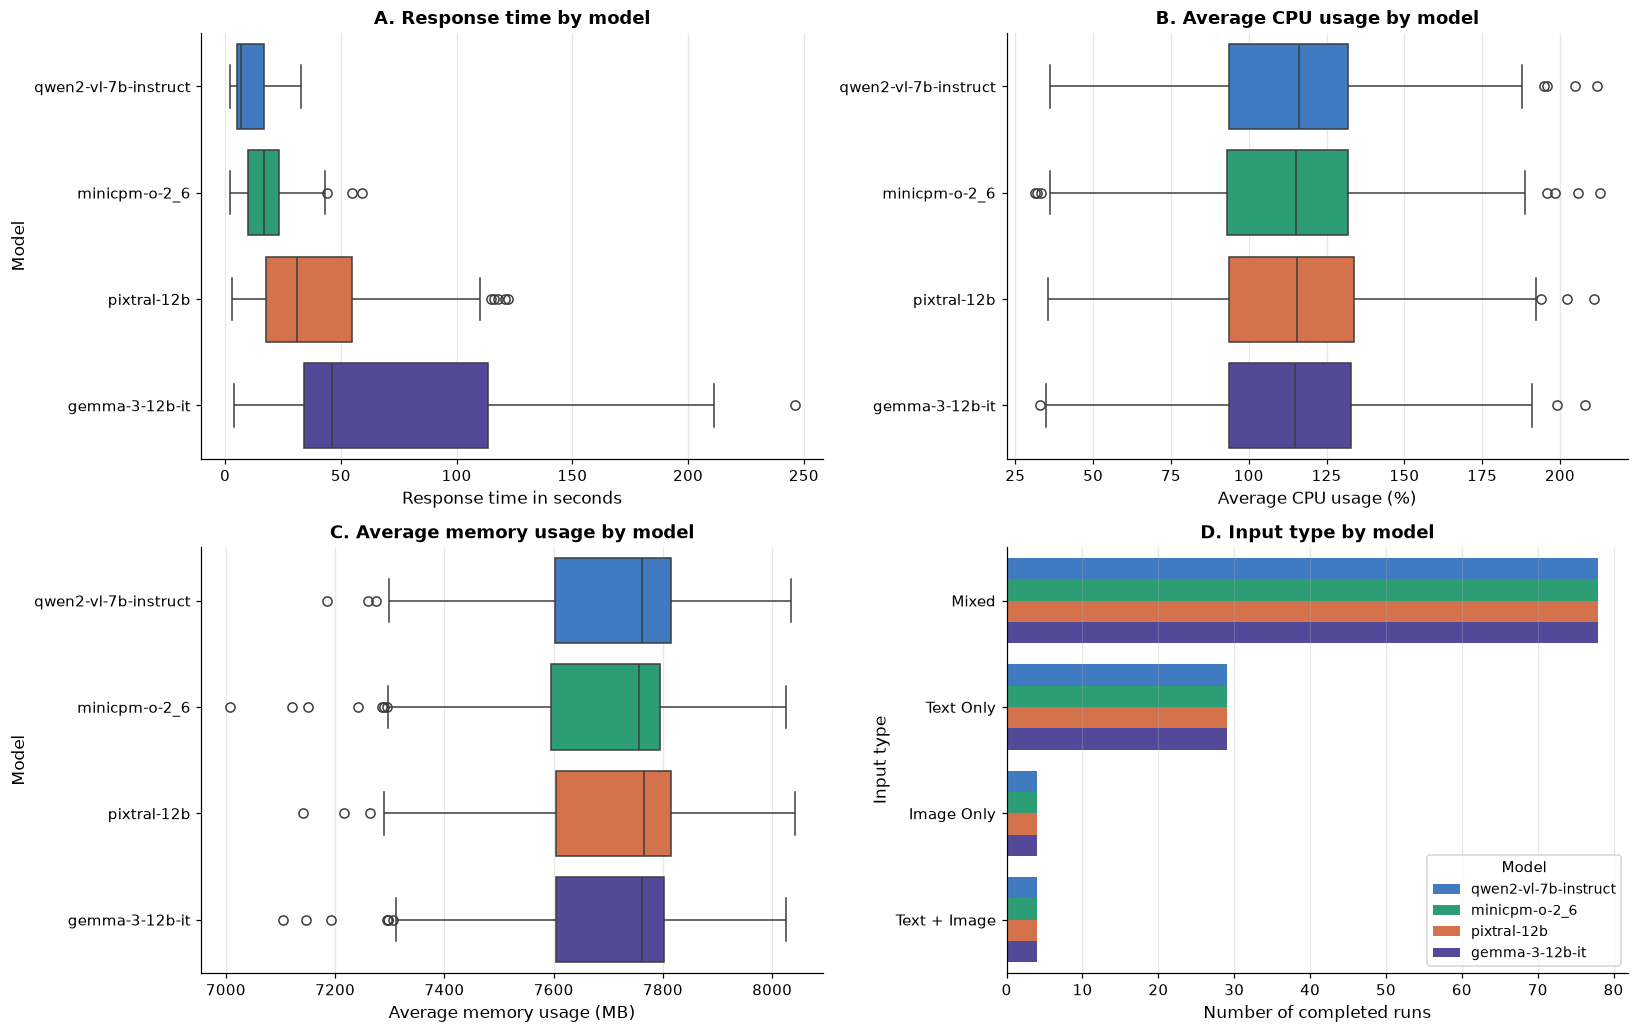

In [10]:
# the input types
input_type_order_for_plots = ['Mixed', 'Text Only', 'Image Only', 'Text + Image']

# Figure
measure_figure, measure_axes = plt.subplots(2, 2, figsize=(15, 9.5))

# top left - response time
sns.boxplot(x='model_time_seconds', y='model', data=successful_runs,
            palette=model_colours, hue='model', orient='h',
            order=model_order, legend=False,
            ax=measure_axes[0][0])
measure_axes[0][0].set_xlabel('Response time in seconds')
measure_axes[0][0].set_ylabel('Model')
measure_axes[0][0].set_title('A. Response time by model')

# top right - CPU usage
sns.boxplot(x='cpu_avg_pct', y='model', data=successful_runs,
            palette=model_colours, hue='model', orient='h',
            order=model_order, legend=False,
            ax=measure_axes[0][1])
measure_axes[0][1].set_xlabel('Average CPU usage (%)')
measure_axes[0][1].set_ylabel('')
measure_axes[0][1].set_title('B. Average CPU usage by model')

# bottom left - memory usage
sns.boxplot(x='memory_avg_mb', y='model', data=successful_runs,
            palette=model_colours, hue='model', orient='h',
            order=model_order, legend=False,
            ax=measure_axes[1][0])
measure_axes[1][0].set_xlabel('Average memory usage (MB)')
measure_axes[1][0].set_ylabel('Model')
measure_axes[1][0].set_title('C. Average memory usage by model')

# bottom right - how many runs each model used of each input type
sns.countplot(y='input_type', data=successful_runs,
              palette=model_colours, hue='model',
              order=input_type_order_for_plots,
              hue_order=model_order,
              ax=measure_axes[1][1])
measure_axes[1][1].set_xlabel('Number of completed runs')
measure_axes[1][1].set_ylabel('Input type')
measure_axes[1][1].set_title('D. Input type by model')
measure_axes[1][1].legend(title='Model', fontsize=9)

# render
plt.tight_layout()
plt.show()

**Findings:**
* **Panel A.** The boxes move steadily to the right from Qwen to Gemma. Neighbouring boxes overlap in part, but the medians and upper quartiles separate clearly. The interquartile range for Gemma-3-12b-it alone, 34 to 113.5 seconds, is wider than the entire observed range of Qwen2-vl-7b-instruct. The slowest single run took 246 seconds against a maximum of 33 seconds for the fastest model. minicpm-o-2_6, pixtral-12b and gemma-3-12b-it show points beyond the upper whisker; Qwen has none, because its slowest run (33 seconds) falls inside its whisker. No model has points below the lower whisker. Long upper whiskers and upper outliers are the picture of a right-skewed distribution.
* **Panels B and C.** In contrast to panel A, CPU and memory look the same for every model. Section 5 tests this further.
* **Panel D.** Every model received the same mix of Input types, so Input Type cannot explain the differences between models.

### CPU and memory summary by model
* Knowing response time by model is not enough to choose a model. If the faster model consumes more resources, the choice becomes a trade-off.
* Memory per call sets how many calls fit on the host at once, and CPU sets how much headroom remains under load. Together they indicate what hardware the deployment needs for each model.

In [11]:
# CPU usage summary for each model
cpu_usage_by_model = (
    successful_runs.groupby('model')['cpu_avg_pct'].describe()
)
print('CPU usage summary for each model:')
cpu_usage_by_model.loc[model_order].round(2)

CPU usage summary for each model:


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
qwen2-vl-7b-instruct,115.0,116.36,34.39,36.00,93.58,116.00,131.96,212.00
minicpm-o-2_6,115.0,114.84,38.03,31.29,92.98,115.33,131.98,212.78
pixtral-12b,115.0,115.93,34.55,35.43,93.74,115.50,133.70,210.79
gemma-3-12b-it,115.0,115.76,36.53,33.03,93.66,115.00,133.00,208.18


In [12]:
# memory usage summary for each model
memory_usage_by_model = (
    successful_runs.groupby('model')['memory_avg_mb'].describe()
)
print('Memory usage summary for each model:')
memory_usage_by_model.loc[model_order].round(2)

Memory usage summary for each model:


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
qwen2-vl-7b-instruct,115.0,7714.59,197.91,7186.0,7602.0,7761.0,7814.0,8034.0
minicpm-o-2_6,115.0,7696.14,217.56,7007.0,7594.5,7757.0,7794.0,8025.0
pixtral-12b,115.0,7715.57,203.23,7141.0,7604.0,7765.0,7814.0,8041.0
gemma-3-12b-it,115.0,7703.96,210.22,7104.0,7604.5,7761.0,7801.5,8026.0


**Findings:** The four models have very similar readings for CPU and Memory measures, the opposite of what the Response Time table showed. CPU means span from 114.84 to 116.36, against within-model standard deviations near 36. Memory means span from 7,696 to 7,716, against within-model standard deviations near 207. In both cases, the difference between models is smaller than the variation inside any one of them.

---
# 3. Distribution shape

Each model's response times are pulled into their own variable, so no name is reused across the analyses below.

In [13]:
# response times for gemma-3-12b-it
gemma_seconds = successful_runs.loc[
    successful_runs['model'] == 'gemma-3-12b-it']['model_time_seconds']

# response times for pixtral-12b
pixtral_seconds = successful_runs.loc[
    successful_runs['model'] == 'pixtral-12b']['model_time_seconds']

# response times for minicpm-o-2_6
minicpm_seconds = successful_runs.loc[
    successful_runs['model'] == 'minicpm-o-2_6']['model_time_seconds']

# response times for qwen2-vl-7b-instruct
qwen_seconds = successful_runs.loc[
    successful_runs['model'] == 'qwen2-vl-7b-instruct']['model_time_seconds']

# the four models' response times, used by every loop in sections 3 and 4
response_times_for_each_model = {
    'gemma-3-12b-it': gemma_seconds,
    'pixtral-12b': pixtral_seconds,
    'minicpm-o-2_6': minicpm_seconds,
    'qwen2-vl-7b-instruct': qwen_seconds,
}

## 3.1 Normal quantile plot of response time, one per model
* Whether response time is normally distributed decides which methods are used later; this is a graphical check.
* Two models can share a mean and behave differently in production if their shapes differ.
* A right-skewed response time means the occasional very slow call, so timeouts and capacity have to be set for the tail rather than for the average.

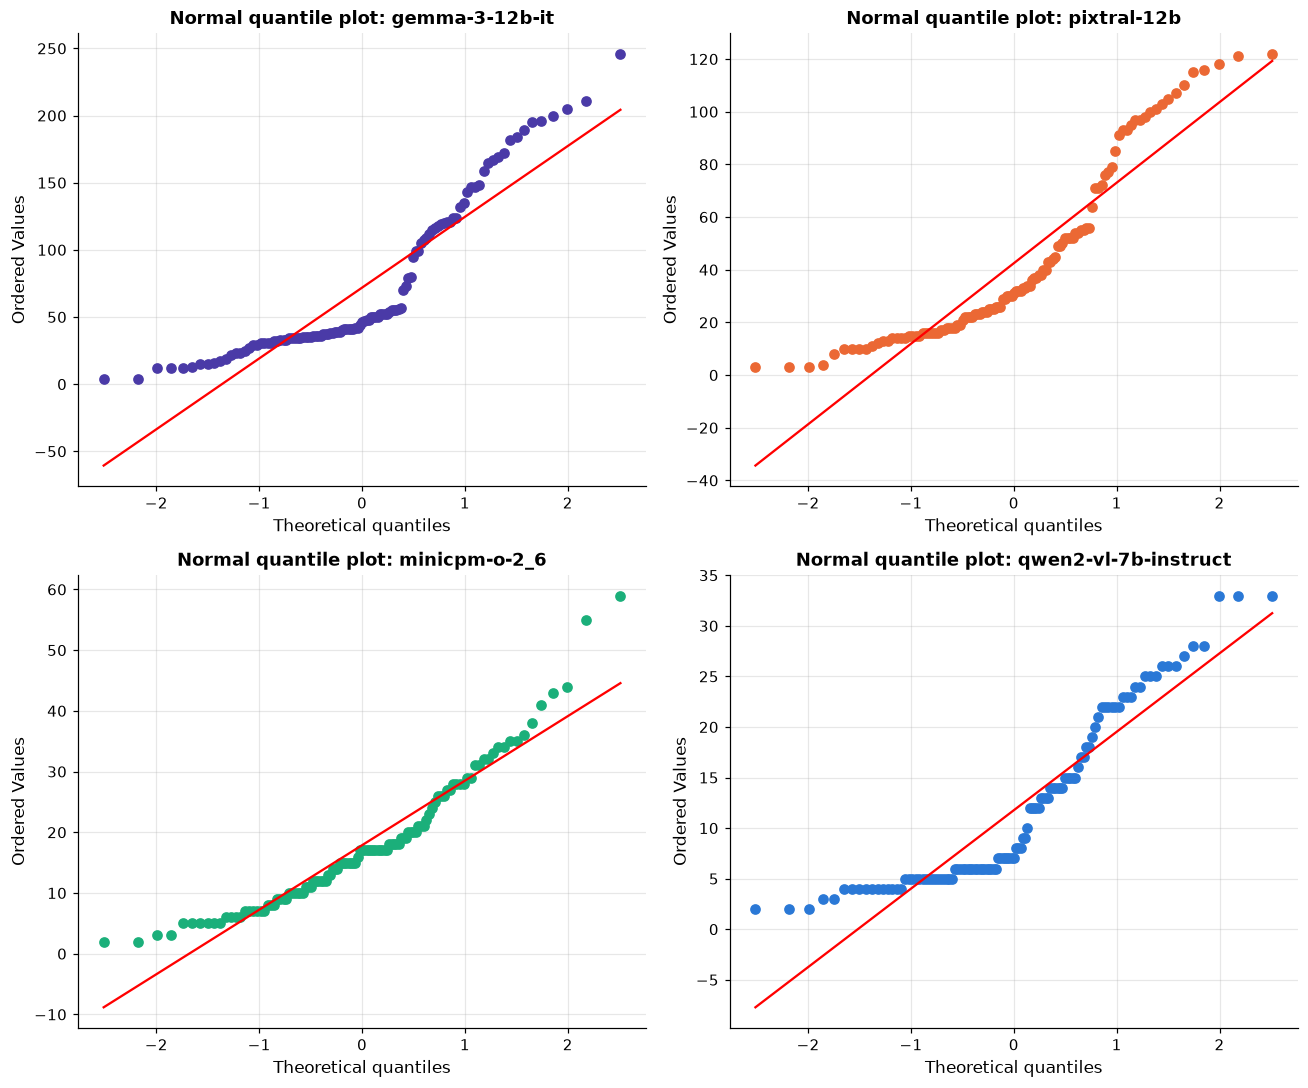

In [14]:
# figure
plt.figure(figsize=(12, 10))

# one panel per model
for panel_position, (model_name, model_times) in enumerate(
        response_times_for_each_model.items(), start=1):
    plt.subplot(2, 2, panel_position)

    # normal quantile plot for this model
    probplot(model_times, dist='norm', plot=pyplot)

    # color the plotted points with this model's color
    plt.gca().get_lines()[0].set_color(model_colours[model_name])

    # the panel title
    quantile_panel_title = 'Normal quantile plot: ' + model_name
    plt.title(quantile_panel_title)

plt.tight_layout()
plt.show()

In [15]:
# sample skewness of response time for each model; positive means a right tail
response_time_skewness = (successful_runs.groupby('model')['model_time_seconds'].skew().loc[model_order].round(2))
response_time_skewness

model
qwen2-vl-7b-instruct    0.89
minicpm-o-2_6           1.16
pixtral-12b             1.02
gemma-3-12b-it          1.14
Name: model_time_seconds, dtype: float64

**Findings:** All four plots bend upward in the upper right, the pattern for data skewed to the right, where the large values are larger than a normal distribution would produce. The sample skewness confirms it numerically: 1.14 for gemma-3-12b-it, 1.16 for minicpm-o-2_6, 1.02 for pixtral-12b and 0.89 for qwen2-vl-7b-instruct, all positive. The shape is consistent across all four models even though their centers are different, so a single right-skewed family is a reasonable starting point for all of them.

## 3.2 Histogram of Response Time and Gamma Shapes
* The data are not normal and are right-skewed, which suggests a Gamma shape.

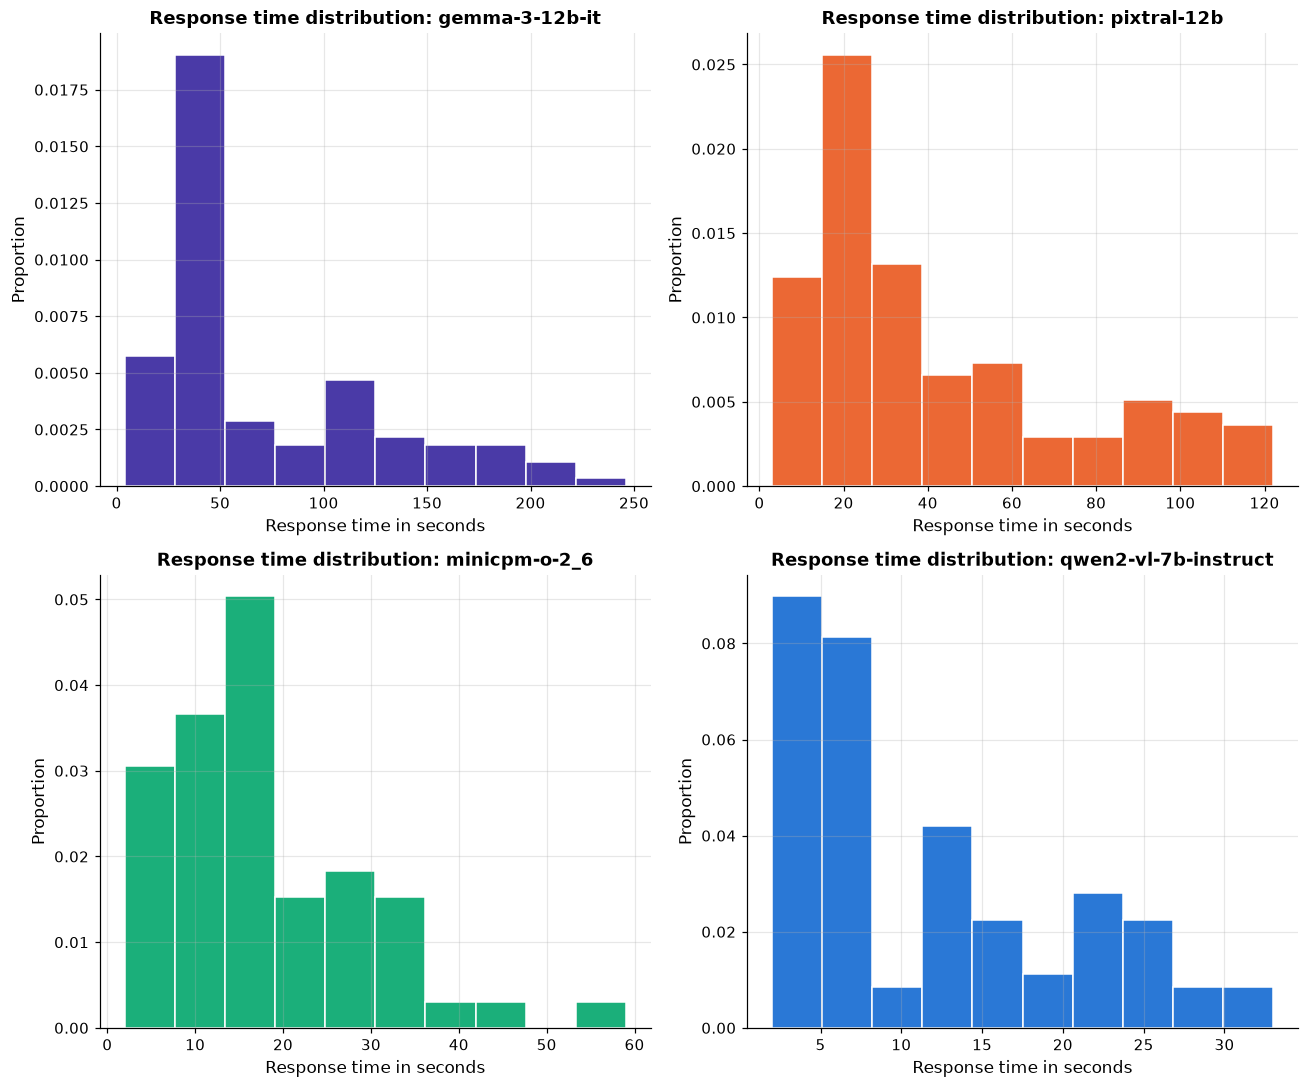

In [16]:
# figure
plt.figure(figsize=(12, 10))

# one panel per model
for panel_position, (model_name, model_times) in enumerate(
        response_times_for_each_model.items(), start=1):
    plt.subplot(2, 2, panel_position)

    plt.hist(model_times, density=True, bins=10,
             color=model_colours[model_name], edgecolor='white')
    plt.ylabel('Density')
    plt.xlabel('Response time in seconds')

    # the panel title, built before it is passed
    histogram_panel_title = 'Response time distribution: ' + model_name
    plt.title(histogram_panel_title)

plt.tight_layout()
plt.show()

### Gamma densities at the observed mean for the **slowest model Gemma-3-12b-it** and  **fastest model Qwen2-vl-7b-instruct**

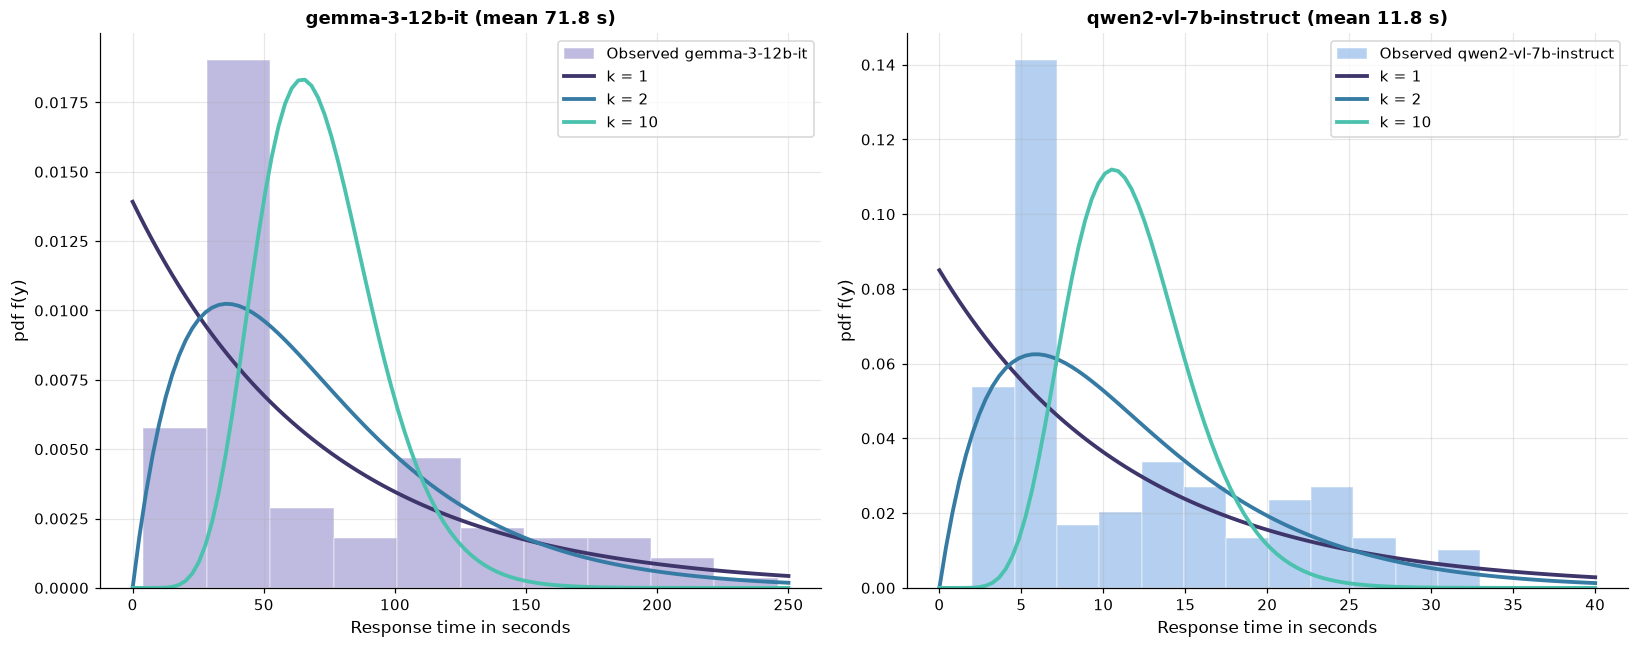

In [17]:
# the slowest and the fastest model are drawn side by side; comparing
# three gamma shapes against each shows which best matches the spread of
# the actual response times, since the mean alone does not determine the
# distribution

# gamma three shape values
gamma_shape_values = np.array([1, 2, 10])

# a sequential palette for the three curves
gamma_curve_colours = sns.color_palette('mako', 3)

# each model's response times
gamma_panel_settings = [
    ('gemma-3-12b-it', gemma_seconds, 250, 10),
    ('qwen2-vl-7b-instruct', qwen_seconds, 40, 12)]

# one row of two panels
gamma_figure, gamma_axes = plt.subplots(1, 2, figsize=(15, 6))

# one panel per model
for panel_position in range(2):
    model_name = gamma_panel_settings[panel_position][0]
    model_seconds = gamma_panel_settings[panel_position][1]
    longest_time_to_draw = gamma_panel_settings[panel_position][2]
    histogram_bins = gamma_panel_settings[panel_position][3]

    # mean response time for this model, which sets all three curves
    model_average = model_seconds.mean()

    # scale = mu / k
    gamma_scale_values = model_average / gamma_shape_values

    # range of response times to draw the curves over
    response_times_to_draw = np.linspace(0, longest_time_to_draw, 100)

    # the observed response times underneath the curves
    gamma_axes[panel_position].hist(
        model_seconds, density=True, bins=histogram_bins,
        color=model_colours[model_name], alpha=0.35,
        edgecolor='white', label='Observed ' + model_name)

    # one curve per shape value
    # k=1 - exponential distribution, highest at zero, falling steadily
    # k=2 - rise then a fall, strongly right-skewed
    # k=10 - hump, closer to symmetric
    for curve_number in range(3):
        gamma_curve_label = ('k = '
                             + str(gamma_shape_values[curve_number]))
        gamma_axes[panel_position].plot(
            response_times_to_draw,
            gamma.pdf(response_times_to_draw,
                      gamma_shape_values[curve_number], 0,
                      gamma_scale_values[curve_number]),
            lw=2.5, color=gamma_curve_colours[curve_number],
            label=gamma_curve_label)

    # title
    gamma_panel_title = ('%s (mean %.1f s)' % (model_name, model_average))

    gamma_axes[panel_position].legend(loc='upper right')
    gamma_axes[panel_position].set_xlabel('Response time in seconds')
    gamma_axes[panel_position].set_ylabel('pdf f(y)')
    gamma_axes[panel_position].set_title(gamma_panel_title)
plt.tight_layout()
plt.show()

**Findings:**
* Every histogram rises sharply at the low end and drops off to the right. None is symmetric, and none looks like a normal distribution.
* The Gemma mean of 71.84 seconds drives the three curves for shape values of 1, 2 and 10. The histogram has a tall peak at about 30 to 50 seconds and a smaller second bump near 100 to 125 seconds. The k = 2 curve follows its overall right-skewed shape far better than the near-symmetric k = 10 curve, but it does not trace the tall peak closely.
* The Qwen mean of 11.77 seconds drives the three curves for shape values of 1, 2 and 10. The histogram has a tall peak at about 5 to 7 seconds and a second spread of runs between about 13 and 27 seconds. Again k = 2 matches the overall shape better than k = 10 without tracing the peak closely.
* Both histograms point toward a right-skewed family such as the Gamma rather than a normal one. Their two-humped shape is consistent with Section 7, where short and long answers form separate groups.

## 3.3 Normal probability against the observed proportion
* Response Times are not normal, but that alone does not say how much it matters.
* We ask a normal curve how many calls should finish within one minute, ask the dataset the same question, and compare the two figures.

> **Assumption:** 60 seconds is a threshold chosen for this comparison. It is not a service target recorded in the data.

In [18]:
# the threshold being tested, in seconds, shared by all four comparisons
time_limit_seconds = 60

In [19]:
# findings for gemma-3-12b-it

# mean of this model's response times
gemma_average = gemma_seconds.mean()

# standard deviation of this model's response times
gemma_spread = gemma_seconds.std()

# if the times followed a normal curve, the share finishing within the limit
gemma_normal_share = norm.cdf(time_limit_seconds, gemma_average,
                              gemma_spread)

# each recorded run that finished at or under the limit
gemma_runs_within_limit = (gemma_seconds <= time_limit_seconds)

# the share that actually finished within the limit
gemma_actual_share = gemma_runs_within_limit.mean()

gemma_comparison_sentence = (
    'gemma-3-12b-it: a normal curve (mean %.2f, sd %.2f) predicts %.2f '
    'of calls within %d seconds; %.2f actually do.'
    % (gemma_average, gemma_spread, gemma_normal_share,
       time_limit_seconds, gemma_actual_share))
print(gemma_comparison_sentence)

# the range to draw the normal curve over, covering the observed times
gemma_curve_times = np.linspace(0, 250, 100)

# the normal curve's height at each of those points
gemma_curve_heights = norm.pdf(gemma_curve_times, gemma_average,
                               gemma_spread)

gemma-3-12b-it: a normal curve (mean 71.84, sd 56.72) predicts 0.42 of calls within 60 seconds; 0.65 actually do.


In [20]:
# findings for pixtral-12b

# mean of this model's response times
pixtral_average = pixtral_seconds.mean()

# standard deviation of this model's response times
pixtral_spread = pixtral_seconds.std()

# if the times followed a normal curve, the share finishing within the limit
pixtral_normal_share = norm.cdf(time_limit_seconds, pixtral_average,
                                pixtral_spread)

# each recorded run that finished at or under the limit
pixtral_runs_within_limit = (pixtral_seconds <= time_limit_seconds)

# the share that actually finished within the limit
pixtral_actual_share = pixtral_runs_within_limit.mean()

pixtral_comparison_sentence = (
    'pixtral-12b: a normal curve (mean %.2f, sd %.2f) predicts %.2f '
    'of calls within %d seconds; %.2f actually do.'
    % (pixtral_average, pixtral_spread, pixtral_normal_share,
       time_limit_seconds, pixtral_actual_share))
print(pixtral_comparison_sentence)

# the range to draw the normal curve over, covering the observed times
pixtral_curve_times = np.linspace(0, 130, 100)

# the normal curve's height at each of those points
pixtral_curve_heights = norm.pdf(pixtral_curve_times, pixtral_average,
                                 pixtral_spread)

pixtral-12b: a normal curve (mean 42.45, sd 32.35) predicts 0.71 of calls within 60 seconds; 0.77 actually do.


In [21]:
# findings for minicpm-o-2_6

# mean of this model's response times
minicpm_average = minicpm_seconds.mean()

# standard deviation of this model's response times
minicpm_spread = minicpm_seconds.std()

# if the times followed a normal curve, the share finishing within the limit
minicpm_normal_share = norm.cdf(time_limit_seconds, minicpm_average,
                                minicpm_spread)

# each recorded run that finished at or under the limit
minicpm_runs_within_limit = (minicpm_seconds <= time_limit_seconds)

# the share that actually finished within the limit
minicpm_actual_share = minicpm_runs_within_limit.mean()

minicpm_comparison_sentence = (
    'minicpm-o-2_6: a normal curve (mean %.2f, sd %.2f) predicts %.2f '
    'of calls within %d seconds; %.2f actually do.'
    % (minicpm_average, minicpm_spread, minicpm_normal_share,
       time_limit_seconds, minicpm_actual_share))
print(minicpm_comparison_sentence)

# the range to draw the normal curve over, covering the observed times
minicpm_curve_times = np.linspace(0, 65, 100)

# the normal curve's height at each of those points
minicpm_curve_heights = norm.pdf(minicpm_curve_times, minicpm_average,
                                 minicpm_spread)

minicpm-o-2_6: a normal curve (mean 17.87, sd 10.94) predicts 1.00 of calls within 60 seconds; 1.00 actually do.


In [22]:
# findings for qwen2-vl-7b-instruct

# mean of this model's response times
qwen_average = qwen_seconds.mean()

# standard deviation of this model's response times
qwen_spread = qwen_seconds.std()

# if the times followed a normal curve, the share finishing within the limit
qwen_normal_share = norm.cdf(time_limit_seconds, qwen_average, qwen_spread)

# each recorded run that finished at or under the limit
qwen_runs_within_limit = (qwen_seconds <= time_limit_seconds)

# the share that actually finished within the limit
qwen_actual_share = qwen_runs_within_limit.mean()

qwen_comparison_sentence = (
    'qwen2-vl-7b-instruct: a normal curve (mean %.2f, sd %.2f) predicts '
    '%.2f of calls within %d seconds; %.2f actually do.'
    % (qwen_average, qwen_spread, qwen_normal_share,
       time_limit_seconds, qwen_actual_share))
print(qwen_comparison_sentence)

# the range to draw the normal curve over, covering the observed times
qwen_curve_times = np.linspace(0, 40, 100)

# the normal curve's height at each of those points
qwen_curve_heights = norm.pdf(qwen_curve_times, qwen_average, qwen_spread)

qwen2-vl-7b-instruct: a normal curve (mean 11.77, sd 8.20) predicts 1.00 of calls within 60 seconds; 1.00 actually do.


### All four models against their normal curves

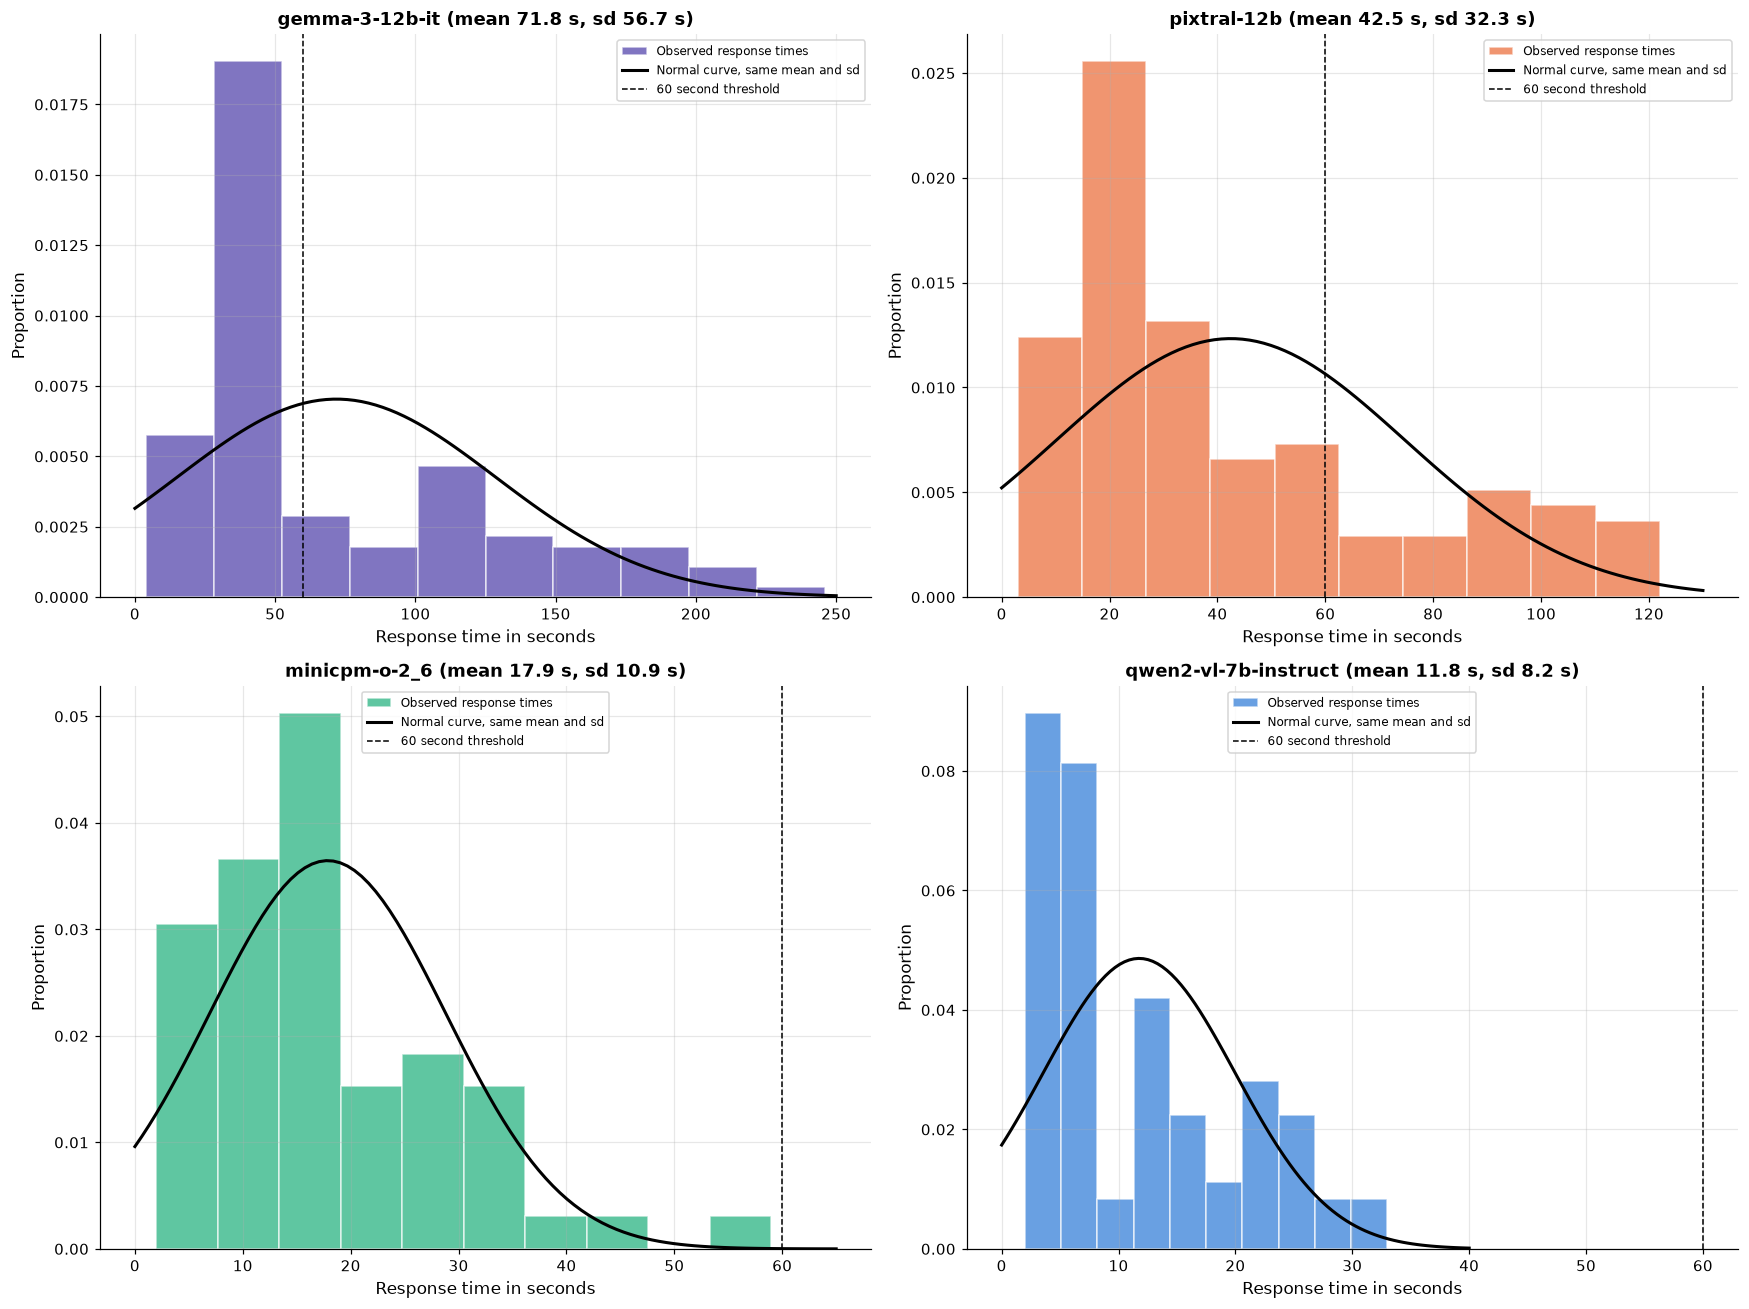

In [23]:
# each model's observed times, curve points, mean and spread
normal_comparison_inputs = {
    'gemma-3-12b-it': (gemma_seconds, gemma_curve_times,
                       gemma_curve_heights, gemma_average, gemma_spread),
    'pixtral-12b': (pixtral_seconds, pixtral_curve_times,
                    pixtral_curve_heights, pixtral_average, pixtral_spread),
    'minicpm-o-2_6': (minicpm_seconds, minicpm_curve_times,
                      minicpm_curve_heights, minicpm_average,
                      minicpm_spread),
    'qwen2-vl-7b-instruct': (qwen_seconds, qwen_curve_times,
                             qwen_curve_heights, qwen_average, qwen_spread),
}

# all four models in one figure, each with its own normal curve
plt.figure(figsize=(16, 12))

for panel_position, (model_name, panel_inputs) in enumerate(
        normal_comparison_inputs.items(), start=1):

    # model's inputs
    (model_times, curve_times, curve_heights,
     model_average, model_spread) = panel_inputs

    plt.subplot(2, 2, panel_position)

    # the observed times as a histogram
    plt.hist(model_times, density=True, bins=10,
             color=model_colours[model_name], edgecolor='white',
             alpha=0.7, label='Observed response times')

    # the normal curve with the same mean and standard deviation
    plt.plot(curve_times, curve_heights, lw=2, color='black',
             label='Normal curve, same mean and sd')

    # a vertical line at the limit the comparison uses - 60 seconds
    plt.axvline(time_limit_seconds, color='black', linestyle='--', lw=1,
                label='60 second threshold')
    plt.ylabel('Density')
    plt.xlabel('Response time in seconds')

    # title
    normal_panel_title = ('%s (mean %.1f s, sd %.1f s)'
                          % (model_name, model_average, model_spread))
    plt.title(normal_panel_title)
    plt.legend(fontsize=8)

# render
plt.tight_layout()
plt.show()

**Findings:**
* For gemma-3-12b-it the normal curve predicts 0.42 of calls finishing within a minute while 0.65 actually do. For pixtral-12b the gap is 0.71 against 0.77. For the two fast models minicpm-o-2_6 and qwen2-vl-7b-instruct, the threshold sits above every observed run, so both figures read 1.00.
* qwen2-vl-7b-instruct has the lowest response time at every quartile and at the maximum; its minimum, 2 seconds, ties minicpm-o-2_6. minicpm-o-2_6 has the smallest gap between mean and median, only 0.87 seconds, so its typical call and its average call are similar. Relative to its own mean it is also the least variable: its standard deviation is 0.61 of its mean (10.94 / 17.87, from the Section 2 table), against 0.70 for qwen, 0.76 for pixtral and 0.79 for gemma.

---
# 4. Uncertainty in the estimates

## 4.1 Standard error of the mean response time per model
* A difference between two sample means needs to be compared against how much those means would move if the benchmark were repeated.
* This helps to narrow down the routing decision for models.

In [24]:
# heading
standard_error_heading = (
    'Standard error of the mean response time, which is how much each '
    'average would move if the benchmark were repeated.')
print(standard_error_heading)
print()

# models
for model_name, model_times in response_times_for_each_model.items():
    model_standard_error = sms.DescrStatsW(model_times).std_mean
    standard_error_sentence = (
        f'{model_name:<22} {model_standard_error:.3f} seconds.')
    print(standard_error_sentence)

Standard error of the mean response time, which is how much each average would move if the benchmark were repeated.

gemma-3-12b-it         5.289 seconds.
pixtral-12b            3.017 seconds.
minicpm-o-2_6          1.020 seconds.
qwen2-vl-7b-instruct   0.765 seconds.


**Findings:** The four standard errors are 5.289 seconds for gemma-3-12b-it, 3.017 for pixtral-12b, 1.020 for minicpm-o-2_6 and 0.765 for qwen2-vl-7b-instruct. The largest of them, 5.289 seconds, is smaller than the smallest gap between any two model means, 6.10 seconds between minicpm-o-2_6 and qwen2-vl-7b-instruct. A pair comparison is sharper: the standard error of the difference between those two means is the square root of 1.020² + 0.765², about 1.28 seconds, so their 6.10-second gap is nearly five standard errors wide.

## 4.2 Confidence interval for each model's mean response time

In [25]:
# the heading
interval_heading = ('95% confidence intervals for mean response time, '
                    'from the t distribution with 115 runs per model.')
print(interval_heading)
print()

# one interval per model
for model_name, model_times in response_times_for_each_model.items():
    model_interval = sms.DescrStatsW(model_times).tconfint_mean()
    interval_sentence = (
        f'{model_name:<22} 95% confident the average response time '
        f'is between {model_interval[0]:.2f} and '
        f'{model_interval[1]:.2f} seconds.')
    print(interval_sentence)

95% confidence intervals for mean response time, from the t distribution with 115 runs per model.

gemma-3-12b-it         95% confident the average response time is between 61.37 and 82.32 seconds.
pixtral-12b            95% confident the average response time is between 36.48 and 48.43 seconds.
minicpm-o-2_6          95% confident the average response time is between 15.85 and 19.89 seconds.
qwen2-vl-7b-instruct   95% confident the average response time is between 10.25 and 13.28 seconds.


**Findings:** The four intervals are 10.25 to 13.28 seconds for qwen2-vl-7b-instruct, 15.85 to 19.89 for minicpm-o-2_6, 36.48 to 48.43 for pixtral-12b and 61.37 to 82.32 for gemma-3-12b-it. No two intervals overlap. They widen as the models get slower, which reflects the growing spread.

## 4.3 Bootstrap intervals for the mean and the median
There are two questions to answer per model: "How long is one call?" and "How long do many calls take altogether?"
* The **median** answers "How long is one call?" Slow runs barely shift it, since it only counts how many values sit on each side.
* The **mean** answers "How long do many calls take altogether?" Total time equals the mean times the number of calls. Slow runs do shift it, because it adds the actual time.

The t intervals rest on the Central Limit Theorem, and response times are right-skewed. The bootstrap resamples the observed runs and assumes nothing about shape.

### 95% bootstrap confidence intervals for MEAN response time.


In [26]:
# heading
bootstrap_heading = (
    '95% bootstrap confidence intervals for MEAN response time.\n'
    'Each interval is resampled from the observed runs, so it makes no assumption that response times follow a normal distribution.')
print(bootstrap_heading)
print()

# one bootstrap interval per model
for model_name, model_times in response_times_for_each_model.items():
    model_sample = (np.array(model_times, dtype=float),)
    model_bootstrap = bootstrap(model_sample, np.mean,
                                confidence_level=0.95,
                                method='percentile', rng=42)
    interval_sentence = (
        f'{model_name:<22} mean response time is between '
        f'{model_bootstrap.confidence_interval.low:.2f} and '
        f'{model_bootstrap.confidence_interval.high:.2f} seconds.')
    print(interval_sentence)

95% bootstrap confidence intervals for MEAN response time.
Each interval is resampled from the observed runs, so it makes no assumption that response times follow a normal distribution.

gemma-3-12b-it         mean response time is between 61.76 and 82.59 seconds.
pixtral-12b            mean response time is between 36.90 and 48.42 seconds.
minicpm-o-2_6          mean response time is between 15.96 and 19.91 seconds.
qwen2-vl-7b-instruct   mean response time is between 10.30 and 13.24 seconds.


**Findings:** All four intervals remain disjoint under the bootstrap and sit within a few tenths of a second of the t intervals, so the model ranking does not depend on the distributional assumption. The intervals widen with the model's spread, from 2.94 seconds across for Qwen to about 20.8 for Gemma, the same pattern the standard errors showed.

### 95% bootstrap confidence intervals for the MEDIAN response time

In [27]:
# heading
median_heading = (
    '95% bootstrap confidence intervals for the MEDIAN response time.\n'
    'The median describes the typical call, while the mean is pulled upward by the minority of very slow runs.')
print(median_heading)
print()

# one bootstrap interval per model
for model_name, model_times in response_times_for_each_model.items():
    model_sample = (np.array(model_times, dtype=float),)
    model_bootstrap = bootstrap(model_sample, np.median,
                                confidence_level=0.95,
                                method='percentile', rng=42)
    model_median = model_times.median()
    median_sentence = (
        f'{model_name:<22} typical call takes '
        f'{model_median:.1f} seconds, and the median lies '
        f'between {model_bootstrap.confidence_interval.low:.1f} and '
        f'{model_bootstrap.confidence_interval.high:.1f} seconds.')
    print(median_sentence)

95% bootstrap confidence intervals for the MEDIAN response time.
The median describes the typical call, while the mean is pulled upward by the minority of very slow runs.

gemma-3-12b-it         typical call takes 46.0 seconds, and the median lies between 39.0 and 52.0 seconds.
pixtral-12b            typical call takes 31.0 seconds, and the median lies between 25.0 and 37.0 seconds.
minicpm-o-2_6          typical call takes 17.0 seconds, and the median lies between 15.0 and 17.0 seconds.
qwen2-vl-7b-instruct   typical call takes 7.0 seconds, and the median lies between 6.0 and 12.0 seconds.


**Findings:**
* The medians are 46.0 seconds for gemma-3-12b-it, 31.0 for pixtral-12b, 17.0 for minicpm-o-2_6 and 7.0 for qwen2-vl-7b-instruct, each below that model's mean. The gap between mean and median is 25.84 seconds for gemma, 11.45 for pixtral, 4.77 for qwen and only 0.87 for minicpm (the smallest gap of the four).
* A typical Gemma call takes about 46 seconds even though the average is 71.84, so quoting only the average overstates the usual wait by almost 26 seconds.
* The intervals keep the ranking intact: Gemma at 39.0 to 52.0 does not overlap Pixtral at 25.0 to 37.0, and Minicpm at 15.0 to 17.0 does not overlap Qwen at 6.0 to 12.0.
* **Why this matters:** the **median** is helpful when setting a user's wait-time expectation; and the **mean** is helpful when sizing hardware, estimating cost or planning how many calls fit in an time frame.
* Every model has some slow runs. A slow Qwen call still finishes within 33 seconds, while a slow Gemma call can take up to about four minutes (246 seconds).

---
# 5. Resource use by model

## 5.1 Difference in CPU usage between models
* Does the speed ranking carry over to processor load? CPU headroom limits how many requests the workflow can run at once, so a model that is faster per call but leaves no headroom can be the slower choice under load.

In [28]:
# all four models' CPU readings
cpu_comparison = mc.MultiComparison(successful_runs['cpu_avg_pct'],
                                    successful_runs['model'])

# Tukey's procedure, which compares every pair at once
cpu_tukey_result = cpu_comparison.tukeyhsd()

print(cpu_tukey_result.summary())

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
    group1            group2        meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------
gemma-3-12b-it        minicpm-o-2_6  -0.9234 0.9974 -13.1335 11.2867  False
gemma-3-12b-it          pixtral-12b   0.1633    1.0 -12.0468 12.3734  False
gemma-3-12b-it qwen2-vl-7b-instruct   0.5954 0.9993 -11.6147 12.8055  False
 minicpm-o-2_6          pixtral-12b   1.0867 0.9957 -11.1234 13.2968  False
 minicpm-o-2_6 qwen2-vl-7b-instruct   1.5188 0.9886 -10.6914 13.7289  False
   pixtral-12b qwen2-vl-7b-instruct   0.4321 0.9997 -11.7781 12.6422  False
---------------------------------------------------------------------------


**Findings:** Not one of the six CPU comparisons is significant. Every interval contains zero, the adjusted p-values run from 0.989 to 1.000, and the largest difference between two models is 1.52 percentage points.

## 5.2 Difference in memory usage between models
* Memory per call is the hard limit on concurrency. It decides how many models can be held in memory at once, the practical constraint on a multi-model workflow.

In [29]:
# all four models' memory readings
memory_comparison = mc.MultiComparison(successful_runs['memory_avg_mb'],
                                       successful_runs['model'])

# Tukey's procedure, which compares every pair at once
memory_tukey_result = memory_comparison.tukeyhsd()

print(memory_tukey_result.summary())

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
    group1            group2        meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------
gemma-3-12b-it        minicpm-o-2_6  -7.8174 0.9918 -78.3297 62.6949  False
gemma-3-12b-it          pixtral-12b  11.6174 0.9742 -58.8949 82.1297  False
gemma-3-12b-it qwen2-vl-7b-instruct  10.6348   0.98 -59.8775 81.1471  False
 minicpm-o-2_6          pixtral-12b  19.4348 0.8928 -51.0775 89.9471  False
 minicpm-o-2_6 qwen2-vl-7b-instruct  18.4522 0.9066 -52.0601 88.9645  False
   pixtral-12b qwen2-vl-7b-instruct  -0.9826    1.0 -71.4949 69.5297  False
---------------------------------------------------------------------------


**Findings:** No pair differs on memory either. Every `reject` reads False, adjusted p-values run from 0.893 to 1.000.

## 5.3 Correlation between response time and resource use
* A different question: within the whole dataset, do slow calls cost more than fast ones?
* If response time and resource use told the same story, one number would summarise both. If not, speed and cost can be treated separately.

In [30]:
# the three measures we are exploring
speed_and_resource_measures = successful_runs[['model_time_seconds',
                                               'cpu_avg_pct',
                                               'memory_avg_mb']]

# correlation for every pair of those three measures
correlations_between_measures = speed_and_resource_measures.corr().round(3)
correlations_between_measures

,model_time_seconds,cpu_avg_pct,memory_avg_mb
model_time_seconds,1.000,0.045,0.004
cpu_avg_pct,0.045,1.000,0.098
memory_avg_mb,0.004,0.098,1.000


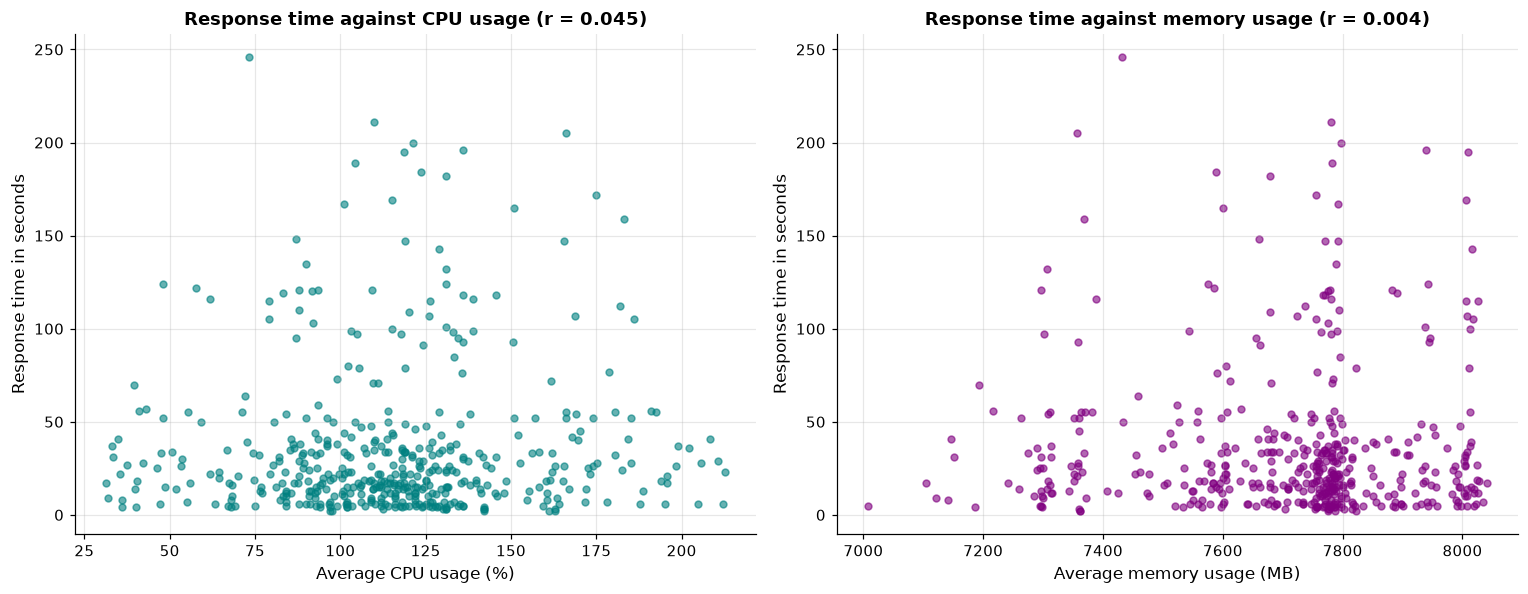

In [31]:
# the correlation shown in each panel title
cpu_correlation = successful_runs['model_time_seconds'].corr(
    successful_runs['cpu_avg_pct'])
memory_correlation = successful_runs['model_time_seconds'].corr(
    successful_runs['memory_avg_mb'])

# the two panel titles
cpu_panel_title = ('Response time against CPU usage (r = %.3f)'
                   % cpu_correlation)
memory_panel_title = ('Response time against memory usage (r = %.3f)'
                      % memory_correlation)

# figure
scatter_figure, scatter_axes = plt.subplots(1, 2, figsize=(14, 5.5))

# left panel - response time against CPU usage
successful_runs.plot(kind='scatter', x='cpu_avg_pct',
                     y='model_time_seconds', color='teal', alpha=0.6,
                     ax=scatter_axes[0])
scatter_axes[0].set_xlabel('Average CPU usage (%)')
scatter_axes[0].set_ylabel('Response time in seconds')
scatter_axes[0].set_title(cpu_panel_title)

# right panel - response time against memory usage
successful_runs.plot(kind='scatter', x='memory_avg_mb',
                     y='model_time_seconds', color='purple', alpha=0.6,
                     ax=scatter_axes[1])
scatter_axes[1].set_xlabel('Average memory usage (MB)')
scatter_axes[1].set_ylabel('Response time in seconds')
scatter_axes[1].set_title(memory_panel_title)

# render
plt.tight_layout()
plt.show()

**Findings:** All three correlations are effectively zero: 0.045 between response time and CPU, 0.004 between response time and memory, and 0.098 between the two resource measures.

---
# 6. CPU-seconds and memory, expanded

Section 5 showed that CPU percentage and memory do not differ between the four models and do not move with response time. That does not mean model choice has no cost. The analyses below show that the resource cost of a model is real, but it lives in **duration** rather than intensity, and that raw CPU percentage is most clearly associated with the **workflow instance** rather than the model.

## 6.1 CPU by workflow instance

In [32]:
# how many rows each bot holds, across all 600
bot_rows_all = benchmark_log['workflow_name'].value_counts()

# how many of those completed
bot_rows_completed = successful_runs['workflow_name'].value_counts()

# median resource and timing figures for each bot
bot_medians = successful_runs.groupby('workflow_name')[
    ['cpu_avg_pct', 'memory_avg_mb', 'workflow_time_seconds',
     'model_time_seconds']].median().round(1)

# logged and completed rows side by side
bot_row_counts = pd.DataFrame({'logged rows': bot_rows_all,
                               'completed rows': bot_rows_completed})
print(bot_row_counts.to_string())
print()
bot_medians

               logged rows  completed rows
workflow_name                             
CSBI Bot 1             536             396
CSBI Bot 2              64              64



,cpu_avg_pct,memory_avg_mb,workflow_time_seconds,model_time_seconds
workflow_name,,,,
CSBI Bot 1,118.7,7763.5,290.0,22.0
CSBI Bot 2,72.4,7724.0,285.0,23.5


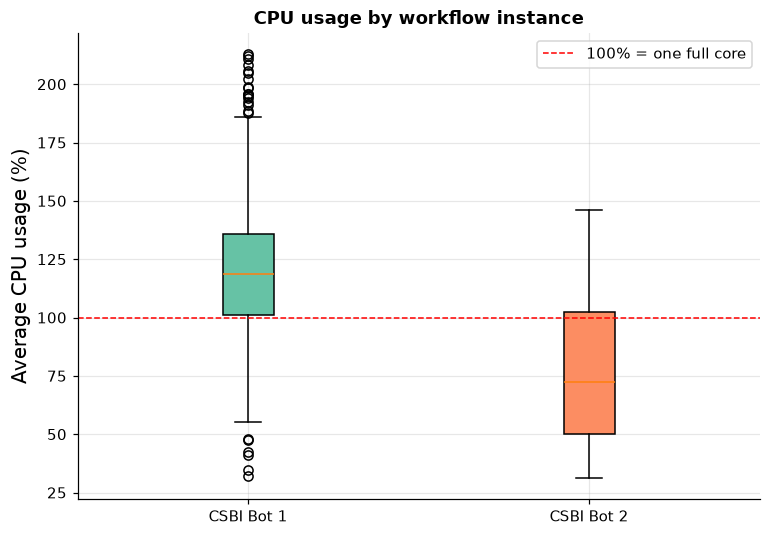

In [33]:
# CPU usage for each bot
cpu_by_bot = [
    successful_runs.loc[
        successful_runs['workflow_name'] == bot_name]['cpu_avg_pct']
    for bot_name in ['CSBI Bot 1', 'CSBI Bot 2']]

plt.figure(figsize=(8, 5.5))

# one color per bot
bot_colours = sns.color_palette('Set2', 2)

# tick_labels
box = plt.boxplot(cpu_by_bot, patch_artist=True,
                  tick_labels=['CSBI Bot 1', 'CSBI Bot 2'])

for patch, colour in zip(box['boxes'], bot_colours):
    patch.set_facecolor(colour)

# 100% marks one full core
plt.axhline(100, color='red', linestyle='--', lw=1,
            label='100% = one full core')
plt.ylabel('Average CPU usage (%)', size=13)
plt.title('CPU usage by workflow instance')
plt.legend()
plt.show()

**Findings:** Model response time is effectively identical across the two bots, with a median of 22.0 seconds for Bot 1 and 23.5 for Bot 2, and memory is close at 7,764 against 7,724 MB. The one measure that separates them is CPU, at a median of 118.7% for Bot 1 against 72.4% for Bot 2. The difference in medians is large, but Bot 2 holds only 64 completed runs and no significance test was run, so it needs confirming. All 140 incomplete runs were logged by Bot 1 (536 logged against 396 completed).

## 6.2 CPU-seconds per call
* CPU percentage is flat across the four models while Response Time is not. Model choice does carry a resource cost, and it arrives through duration rather than intensity.
* **CPU-seconds per call = (average CPU % / 100) x model time in seconds.** Dividing by 100 converts the percentage into a fraction of one core, and multiplying by the duration gives the work performed. This is the number that converts a model choice into CPU time, which capacity planning depends on. It covers CPU only; GPU use is not part of this measure.

In [34]:
# a working copy so the derived column does not alter successful_runs
measured_runs = successful_runs.copy()

# CPU as a fraction of one core rather than a percentage
cpu_as_core_fraction = measured_runs['cpu_avg_pct'] / 100

# fraction multiplied by how long the call ran
measured_runs['cpu_seconds_per_call'] = (
    cpu_as_core_fraction * measured_runs['model_time_seconds'])

# count, median and mean CPU-seconds for each model
print('Count, median and mean CPU-seconds for each model')
cpu_seconds_by_model = (
    measured_runs.groupby('model')['cpu_seconds_per_call']
    .agg(['count', 'median', 'mean']).round(2))
cpu_seconds_by_model.loc[model_order]

Count, median and mean CPU-seconds for each model


,count,median,mean
model,,,
qwen2-vl-7b-instruct,115,9.84,13.84
minicpm-o-2_6,115,16.56,20.24
pixtral-12b,115,34.90,50.23
gemma-3-12b-it,115,49.92,84.86


### Compare each model with the fastest model, qwen

In [35]:
# the model every other model is compared against, the fastest one
baseline_model_name = 'qwen2-vl-7b-instruct'

# median and mean CPU-seconds for every model
cpu_seconds_by_model = (
    measured_runs.groupby('model')['cpu_seconds_per_call']
    .agg(['median', 'mean']))

# the baseline model's two figures
baseline_median_cpu_seconds = cpu_seconds_by_model.loc[
    baseline_model_name, 'median']
baseline_mean_cpu_seconds = cpu_seconds_by_model.loc[
    baseline_model_name, 'mean']

# how many times more work a typical call performs than the baseline
cpu_seconds_by_model['times the work'] = (
    cpu_seconds_by_model['median'] / baseline_median_cpu_seconds)

# extra CPU-seconds per call, on average, compared with the baseline
extra_cpu_seconds_per_call = (cpu_seconds_by_model['mean']
                              - baseline_mean_cpu_seconds)

# CPU-hours saved per 1,000 calls by routing to the baseline instead;
# multiply by 1,000 calls, then divide by 3,600 seconds per hour
cpu_seconds_by_model['CPU-hours saved per 1,000 calls'] = (
    extra_cpu_seconds_per_call * 1000 / 3600)

# heading
cpu_seconds_heading = (
    'Processing work per call, as CPU-seconds = CPU% / 100 x seconds.\n'
    'Each model is compared against ' + baseline_model_name
    + ', the fastest.')
print(cpu_seconds_heading)
print()
cpu_seconds_table = cpu_seconds_by_model.loc[model_order].round(2)
print(cpu_seconds_table.to_string())

Processing work per call, as CPU-seconds = CPU% / 100 x seconds.
Each model is compared against qwen2-vl-7b-instruct, the fastest.

                      median   mean  times the work  CPU-hours saved per 1,000 calls
model                                                                               
qwen2-vl-7b-instruct    9.84  13.84            1.00                             0.00
minicpm-o-2_6          16.56  20.24            1.68                             1.78
pixtral-12b            34.90  50.23            3.55                            10.11
gemma-3-12b-it         49.92  84.86            5.07                            19.73


### Processing work per call by model

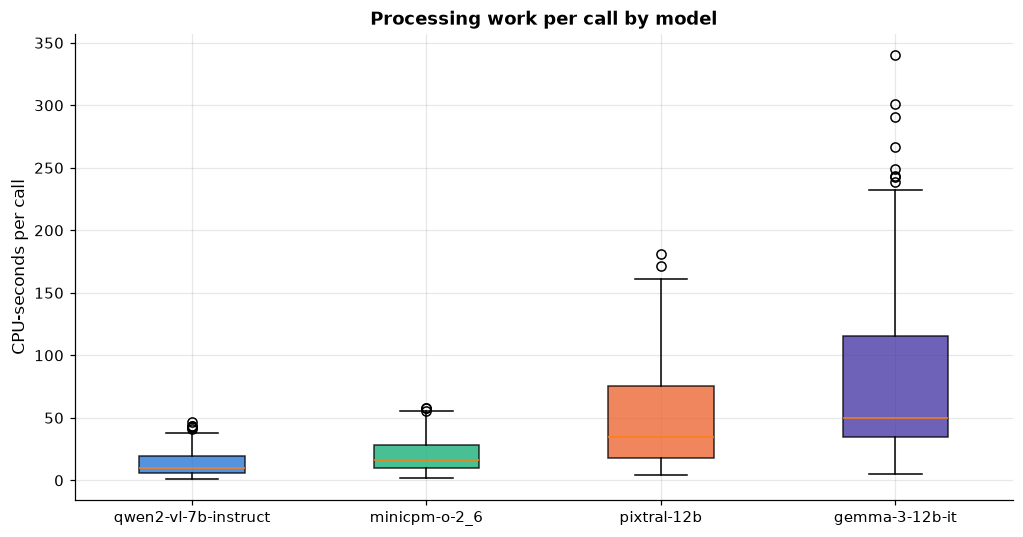

In [36]:
# CPU-seconds for each model, fastest to slowest
cpu_seconds_lists = [
    measured_runs.loc[measured_runs['model'] == model_name,
                      'cpu_seconds_per_call']
    for model_name in model_order]

plt.figure(figsize=(11, 5.5))
box = plt.boxplot(cpu_seconds_lists, patch_artist=True,
                  tick_labels=model_order)

# fill each box with its model's colour
for patch, model_name in zip(box['boxes'], model_order):
    patch.set_facecolor(model_colours[model_name])
    patch.set_alpha(0.8)
plt.ylabel('CPU-seconds per call')
plt.title('Processing work per call by model')
plt.show()

**Findings:** Median CPU-seconds per call rise from 9.84 for qwen2-vl-7b-instruct through 16.56 for minicpm-o-2_6 and 34.90 for pixtral-12b to 49.92 for gemma-3-12b-it, so a typical Gemma call uses 5.07 times the CPU-seconds of a typical Qwen call. These box plots show separate readings, in sharp contrast to the CPU-percentage box plots in Section 2, which are similar. The means are higher than the medians in every case, and the gap widens with the model (Gemma 84.86 mean against 49.92 median) because of the right tail in response time. That matters for the business figure, because a total across many calls is governed by the mean: **routing 1,000 calls from Gemma to Qwen saves 71,026 CPU-seconds, or 19.7 CPU-hours**. Because CPU percentage is nearly constant across models, CPU-seconds is close to response time multiplied by about 1.2, so this measure restates the speed gap in hardware terms rather than adding a separate cost signal.

## 6.3 CPU against response time, one panel per model
* This shows that the variation between models is entirely in duration while intensity stays fixed. CPU tuning alone is unlikely to close the gap between models, because the models are not drawing different amounts of CPU in the first place.

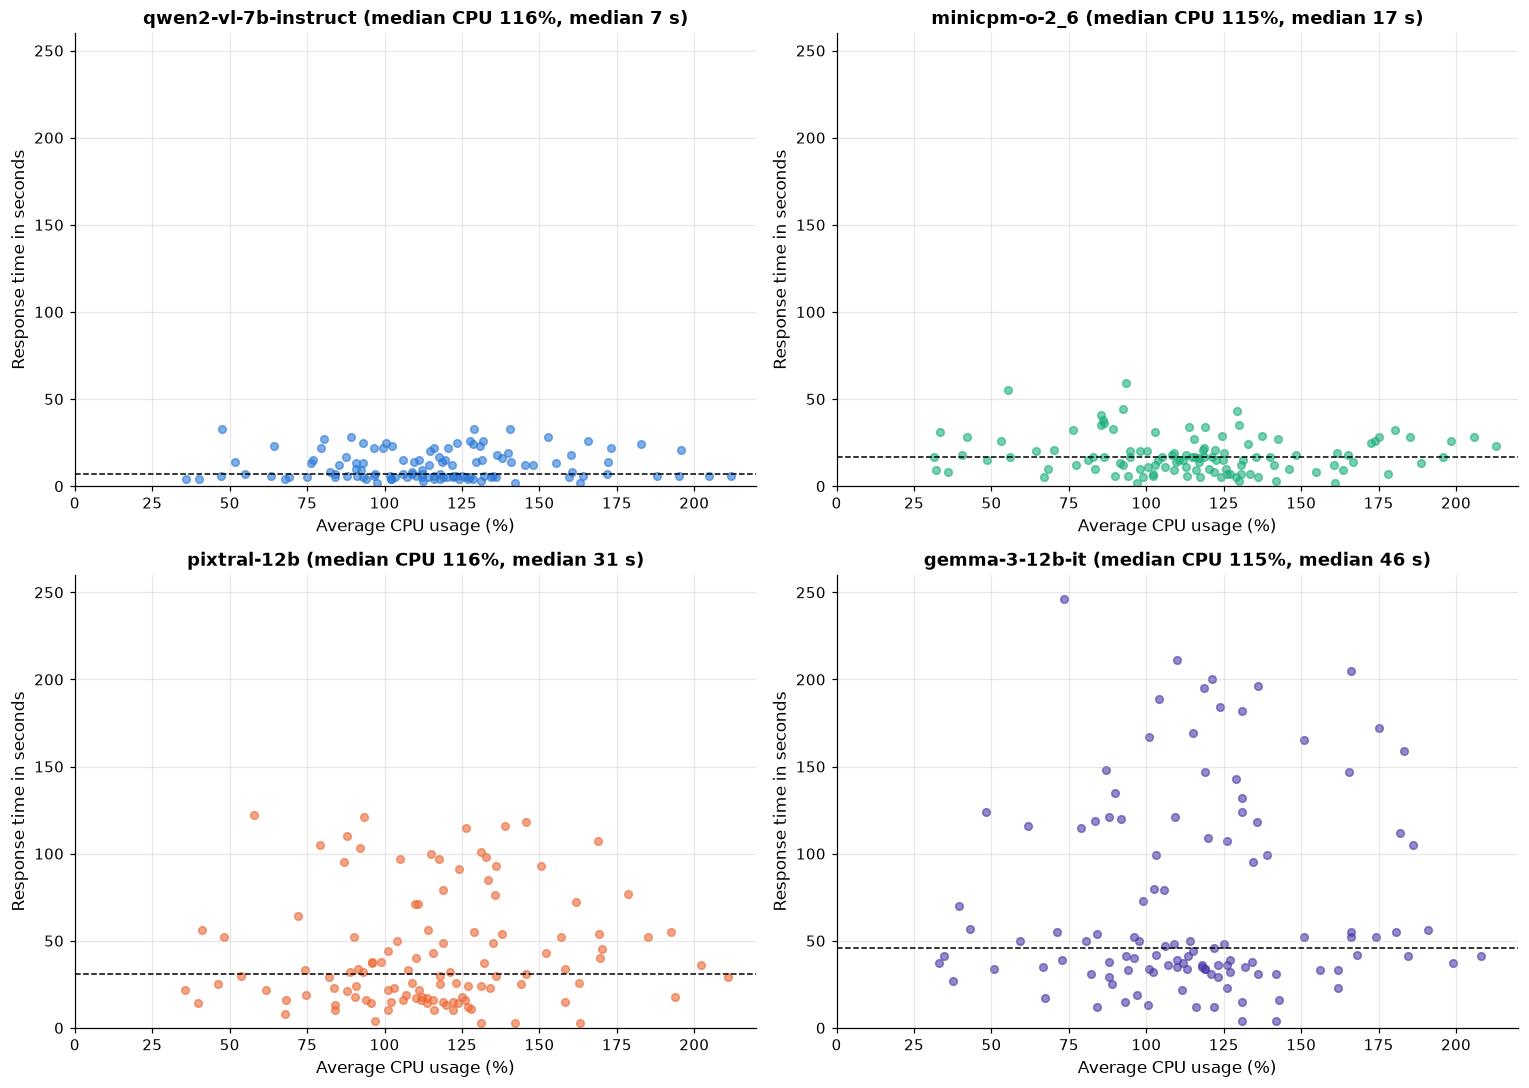

In [37]:
# figure
plt.figure(figsize=(14, 10))

# one panel per model
for panel_position, model_name in enumerate(model_order, start=1):

    plt.subplot(2, 2, panel_position)
    # model's runs
    model_rows = measured_runs.loc[measured_runs['model'] == model_name]

    # CPU against response time
    plt.scatter(model_rows['cpu_avg_pct'],
                model_rows['model_time_seconds'],
                color=model_colours[model_name], alpha=0.6, s=25)

    # model's median response time
    model_median_time = model_rows['model_time_seconds'].median()

    # horizontal line at median
    plt.axhline(model_median_time, color='black', linestyle='--', lw=1)

    # the same limits on every panel
    plt.xlim(0, 220)
    plt.ylim(0, 260)

    # model's median CPU, for the panel title
    model_median_cpu = model_rows['cpu_avg_pct'].median()

    # title
    panel_title = ('%s (median CPU %.0f%%, median %.0f s)'
                   % (model_name, model_median_cpu, model_median_time))

    plt.xlabel('Average CPU usage (%)')
    plt.ylabel('Response time in seconds')
    plt.title(panel_title)

plt.tight_layout()
plt.show()

**Findings:** All four panels show the same horizontal spread of CPU usage, clustered near 115%, and very different vertical spreads. Qwen's points sit in a compressed band below 35 seconds, while Gemma's stretch to 246, and the dashed median lines sit at 7 and 46 seconds, respectively. Within each panel, the points form a vertical cloud rather than a slope, consistent with CPU and response time being unrelated inside a given model. The difference between models is entirely vertical: the same processing intensity sustained for very different durations. This is why CPU percentage alone misses the efficiency picture, and CPU-seconds captures it.

## 6.4 Memory against workflow time
* Memory did not differ between models because it was being compared against the model call. Here it is compared against the full workflow duration instead.
* This establishes what the memory measurement actually describes, which decides whether memory can inform model selection at all.

In [38]:
# correlation between memory and the full workflow duration
memory_workflow_correlation = measured_runs['memory_avg_mb'].corr(
    measured_runs['workflow_time_seconds'])

# correlation between memory and the model call alone
memory_model_correlation = measured_runs['memory_avg_mb'].corr(
    measured_runs['model_time_seconds'])

# median duration of the whole workflow and of the model call
median_workflow_time = measured_runs['workflow_time_seconds'].median()
median_model_time = measured_runs['model_time_seconds'].median()

# the model call as a share of total elapsed time
model_share_of_workflow = median_model_time / median_workflow_time

# figures
memory_workflow_rounded = round(memory_workflow_correlation, 3)
memory_model_rounded = round(memory_model_correlation, 3)
model_share_rounded = round(100 * model_share_of_workflow, 1)

correlation_sentence = (
    'Memory correlates at '
    + str(memory_workflow_rounded)
    + ' with workflow duration but at only '
    + str(memory_model_rounded)
    + ' with the model call.'
)
share_sentence = (
    'The model call accounts for '
    + str(model_share_rounded)
    + '% of median elapsed time.'
)
print(correlation_sentence)
print(share_sentence)

Memory correlates at 0.496 with workflow duration but at only 0.004 with the model call.
The model call accounts for 7.6% of median elapsed time.


In [39]:
# the same two correlations computed separately inside each model
memory_correlations_by_model = pd.DataFrame({
    'memory vs workflow time': [
        measured_runs.loc[measured_runs['model'] == model_name,
                          'memory_avg_mb'].corr(
            measured_runs.loc[measured_runs['model'] == model_name,
                              'workflow_time_seconds'])
        for model_name in model_order],
    'memory vs model time': [
        measured_runs.loc[measured_runs['model'] == model_name,
                          'memory_avg_mb'].corr(
            measured_runs.loc[measured_runs['model'] == model_name,
                              'model_time_seconds'])
        for model_name in model_order]},
    index=model_order).round(3)
memory_correlations_by_model

,memory vs workflow time,memory vs model time
qwen2-vl-7b-instruct,0.495,-0.076
minicpm-o-2_6,0.497,-0.106
pixtral-12b,0.493,0.045
gemma-3-12b-it,0.503,0.020


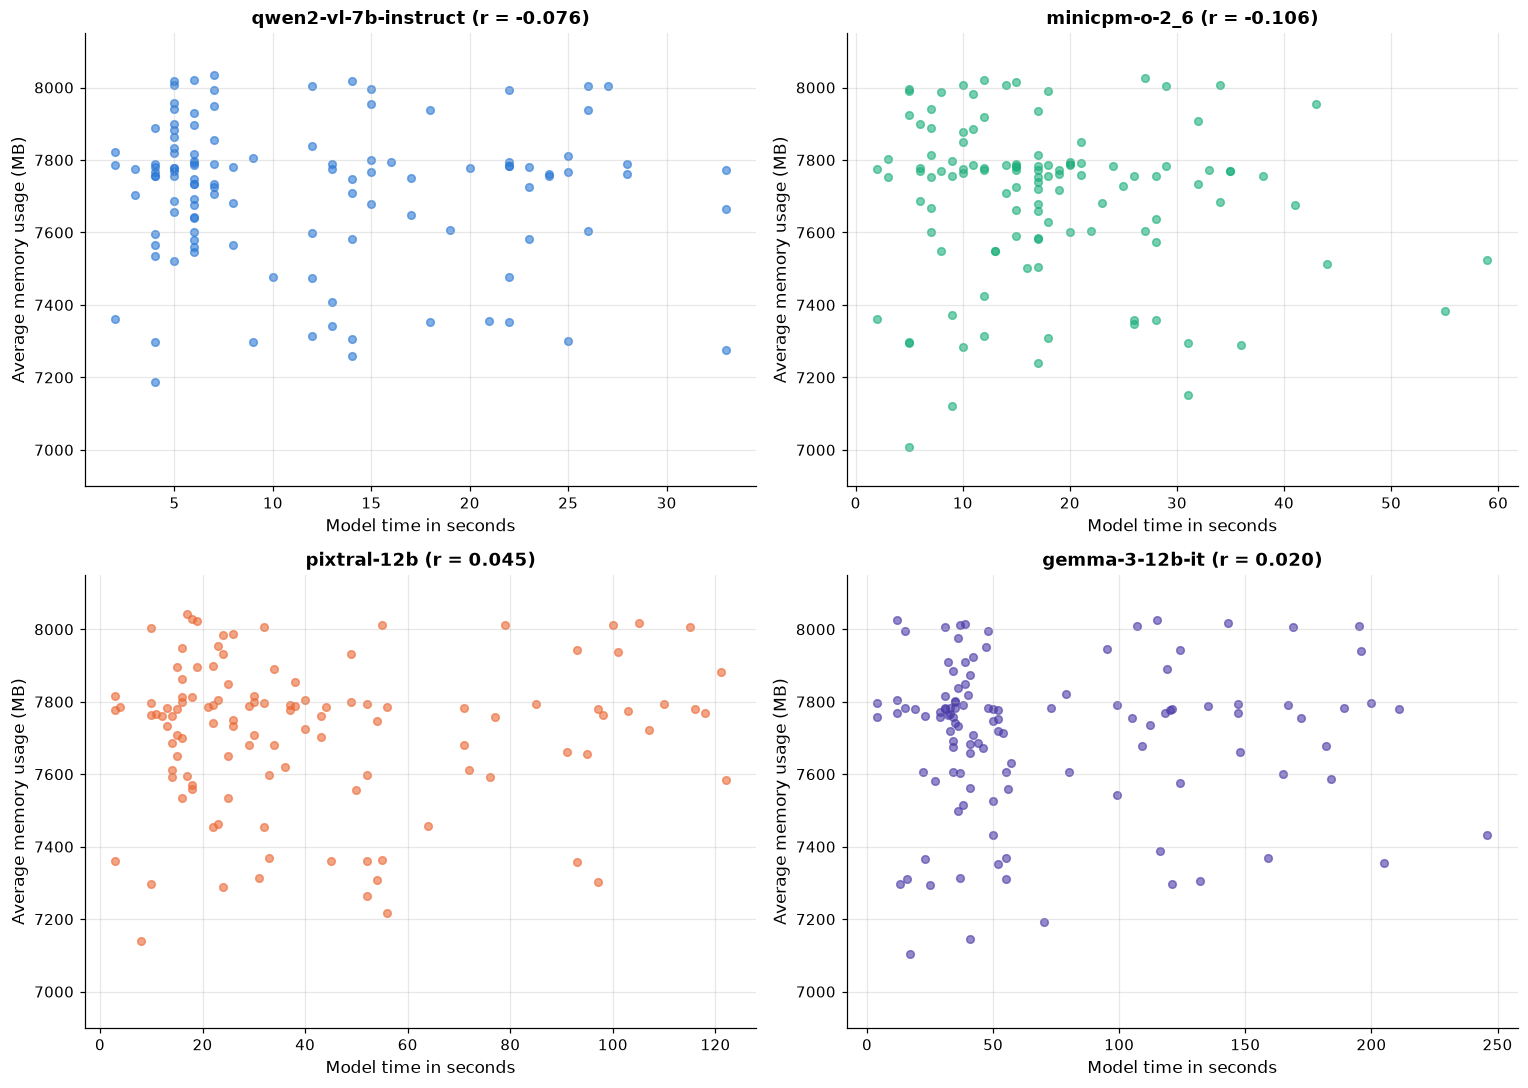

In [40]:
# Showing memory against that model's response time
plt.figure(figsize=(14, 10))

# one panel per model
for panel_position, model_name in enumerate(model_order, start=1):

    plt.subplot(2, 2, panel_position)

    # model's runs
    model_rows = measured_runs.loc[measured_runs['model'] == model_name]

    # memory against this model's own call duration
    plt.scatter(model_rows['model_time_seconds'],
                model_rows['memory_avg_mb'],
                color=model_colours[model_name], alpha=0.6, s=25)

    # model's correlation, computed before the title is built
    model_memory_correlation = model_rows['memory_avg_mb'].corr(
        model_rows['model_time_seconds'])

    # the same limits on every panel so the models compare directly
    plt.ylim(6900, 8150)

    # title
    panel_title = ('%s (r = %.3f)' % (model_name, model_memory_correlation))

    plt.xlabel('Model time in seconds')
    plt.ylabel('Average memory usage (MB)')
    plt.title(panel_title)

plt.tight_layout()
plt.show()

**Findings:** Memory correlates with total workflow duration at 0.495 for qwen2-vl-7b-instruct, 0.497 for minicpm-o-2_6, 0.493 for pixtral-12b and 0.503 for gemma-3-12b-it, a spread of just 0.010 across four models. Against the model call itself the same correlations collapse to -0.076, -0.106, 0.045 and 0.020, all effectively zero. The model call accounts for only 7.6% of median elapsed workflow time. The relationship belongs to the workflow, not to any model, so **model choice did not change the recorded memory; memory should be sized against the workflow.** The near-identical readings for 7B and 12B models suggest this metric records the host rather than each model's own memory footprint.

### Comparing Response Time, CPU and Memory relative to the fastest model **Qwen2-vl-7b-instruct**

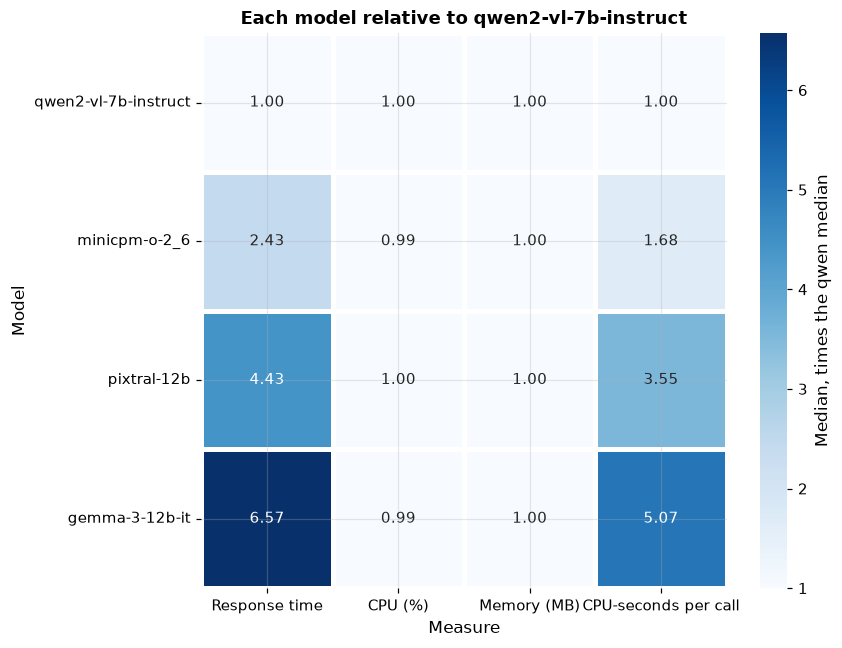

In [41]:
# measures to compare: the three key ones plus CPU-seconds
measure_columns = ['model_time_seconds', 'cpu_avg_pct',
                   'memory_avg_mb', 'cpu_seconds_per_call']

# median of each measure for each model
median_by_model = measured_runs.groupby('model')[measure_columns].median()

median_by_model = median_by_model.loc[model_order]

# fast model - qwen's medians, the baseline every model is divided by
baseline_medians = median_by_model.loc['qwen2-vl-7b-instruct']

# how many times qwen's median each model shows
times_the_baseline = median_by_model / baseline_medians

# labels for the heatmap
times_the_baseline.columns = ['Response time', 'CPU (%)',
                              'Memory (MB)', 'CPU-seconds per call']

# figure
baseline_figure, baseline_axes = plt.subplots(figsize=(8, 6))
sns.heatmap(times_the_baseline, annot=True, fmt='.2f', cmap='Blues',
            vmin=1, linewidths=2, linecolor='white',
            cbar_kws={'label': 'Median, times the qwen median'},
            ax=baseline_axes)
baseline_axes.set_xlabel('Measure')
baseline_axes.set_ylabel('Model')
baseline_axes.set_title('Each model relative to qwen2-vl-7b-instruct')
plt.tight_layout()
plt.show()

### Correlation between Response Time, CPU, Memory and Workflow Time

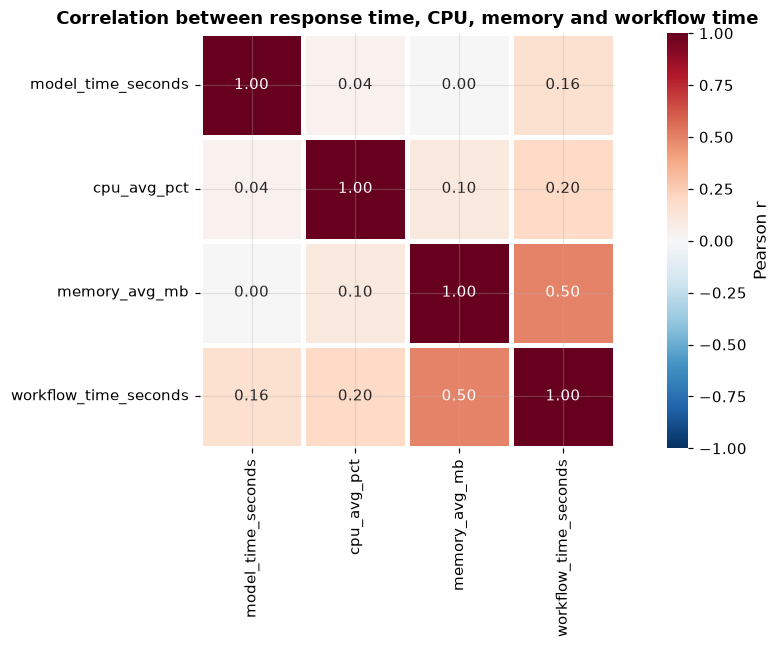

In [42]:
# key main measures plus workflow time
correlation_columns = ['model_time_seconds', 'cpu_avg_pct',
                       'memory_avg_mb', 'workflow_time_seconds']

# Pearson correlation for every pair of those measures
measure_correlations = successful_runs[correlation_columns].corr()

# figure
correlation_figure, correlation_axes = plt.subplots(figsize=(10, 6))

# one cell per pair
sns.heatmap(measure_correlations, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, linewidths=2,
            linecolor='white', cbar_kws={'label': 'Pearson r'},
            ax=correlation_axes)
correlation_axes.set_title('Correlation between response time, '
                           'CPU, memory and workflow time')
plt.tight_layout()
plt.show()

---
# 7. Request and output characteristics

The research question asks about **request characteristics** as well as models. This section looks at the characteristic a router could act on: the length of the answer the model writes (`model_output`).

## 7.1 Output length as a driver of response time
* A model generates its answer piece by piece, so a longer answer should take longer. If that holds, the length of the answer a task needs is a request characteristic a router can use.

In [43]:
# number of characters in each model
measured_runs['output_characters'] = (
    measured_runs['model_output'].fillna('').str.len())

# correlation between answer length and response time, all models together
output_length_correlation = measured_runs['output_characters'].corr(
    measured_runs['model_time_seconds'])

# the same correlation inside each model
output_length_correlation_by_model = pd.Series(
    [measured_runs.loc[measured_runs['model'] == model_name,
                       'output_characters'].corr(
        measured_runs.loc[measured_runs['model'] == model_name,
                          'model_time_seconds'])
     for model_name in model_order],
    index=model_order).round(3)

output_length_sentence = ('Across all 460 runs, answer length and response '
                          'time correlate at r = %.3f.'
                          % output_length_correlation)
print(output_length_sentence)
print()
print('Correlation inside each model:')
output_length_correlation_by_model

Across all 460 runs, answer length and response time correlate at r = 0.909.

Correlation inside each model:


qwen2-vl-7b-instruct    0.954
minicpm-o-2_6           0.818
pixtral-12b             0.977
gemma-3-12b-it          0.954
dtype: float64

### Writing pace: seconds per 1,000 characters
* If answer length drives response time, the speed comparison is how long each model takes to write the same amount of characters.
* Seconds per 1,000 characters = response time / (output characters / 1,000)

### Median answer length and median writing pace for each model

In [44]:
# answer length in thousands of characters
output_thousands_of_characters = measured_runs['output_characters'] / 1000

# seconds spent per 1,000 characters of answer
measured_runs['seconds_per_1000_characters'] = (
    measured_runs['model_time_seconds'] / output_thousands_of_characters)

# median answer length and median writing pace for each model
writing_pace_by_model = measured_runs.groupby('model')[
    ['output_characters', 'seconds_per_1000_characters']].median()
writing_pace_by_model = writing_pace_by_model.loc[model_order].round(1)
writing_pace_by_model

,output_characters,seconds_per_1000_characters
model,,
qwen2-vl-7b-instruct,471.0,15.0
minicpm-o-2_6,1173.0,13.0
pixtral-12b,1050.0,28.0
gemma-3-12b-it,1194.0,32.8


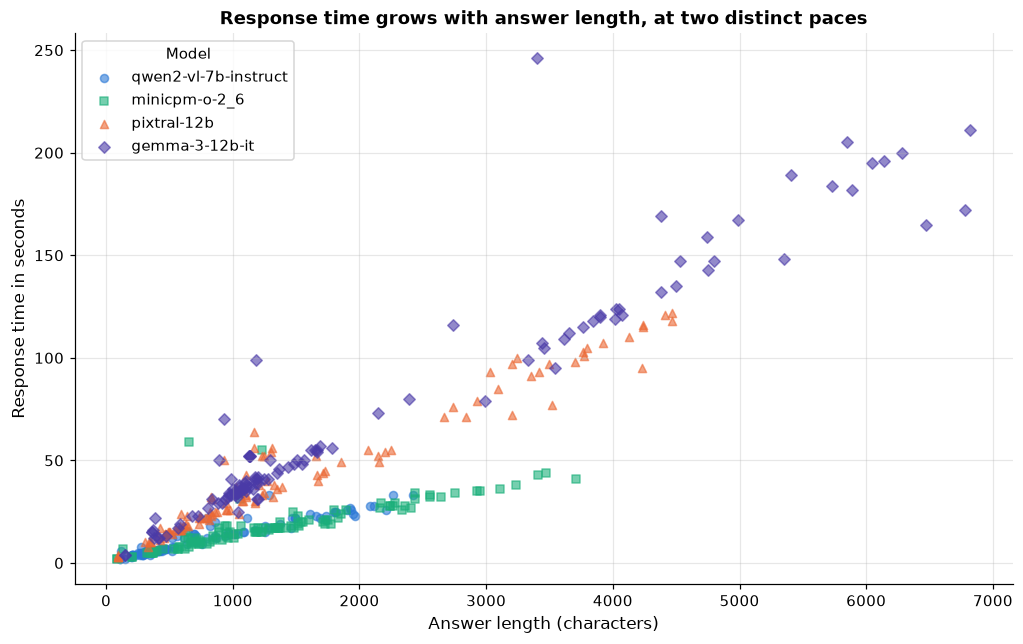

In [45]:
# response time against answer length, all four models on one plot
plt.figure(figsize=(11, 6.5))

# a different marker per model so identity does not rely on color alone
model_markers = dict(zip(model_order, ['o', 's', '^', 'D']))

for model_name in model_order:

    # model's runs
    model_rows = measured_runs.loc[measured_runs['model'] == model_name]

    # one point per call
    plt.scatter(model_rows['output_characters'],
                model_rows['model_time_seconds'],
                color=model_colours[model_name],
                marker=model_markers[model_name],
                alpha=0.6, s=28, label=model_name)

plt.xlabel('Answer length (characters)')
plt.ylabel('Response time in seconds')
plt.title('Response time grows with answer length, at two distinct paces')
plt.legend(title='Model')
plt.show()

**Findings:**
* Answer length tracks response time closely: r = 0.91 across all runs, and between 0.82 and 0.98 inside each model.
* The models fall into **two tiers**. minicpm-o-2_6 (13.0 s per 1,000 characters) and qwen2-vl-7b-instruct (15.0 s) write about **twice as fast** as pixtral-12b (28.0 s) and gemma-3-12b-it (32.8 s).
* Qwen is the fastest model for two reasons: **it writes quickly, and it writes the shortest answers (median 471 characters against 1,050 to 1,194 for the other three).** minicpm writes answers about as long as gemma's in less than half the time per character, which makes it the efficient choice when a task needs a long answer.

---
# 8. Learned dependency structure

### CPU, Memory and Response time - BIC score on 460 completed runs
* The project has tested relationships one pair at a time. A structure search does the opposite: it is given every variable at once and asked which dependencies are worth keeping, scoring each candidate graph against the data with the BIC score.
* Expert knowledge forbids any edge from an outcome back to a design choice, since a measurement taken after the call cannot cause how the call was set up.
* A diagram of what depends on what is far easier for a non-technical audience to read, and it supports routing recommendations.

In [46]:
# quartile bands for the three measures, and design variables
binned_runs = pd.DataFrame({
    'model': successful_runs['model'],
    'input_type': successful_runs['input_type'],
    'trigger': successful_runs['how_to_start'].str[:18],
    'bot': successful_runs['workflow_name'],
    'response_time_band': pd.qcut(successful_runs['model_time_seconds'],
                                  4, labels=['Q1', 'Q2', 'Q3', 'Q4']),
    'cpu_band': pd.qcut(successful_runs['cpu_avg_pct'], 4,
                        labels=['Q1', 'Q2', 'Q3', 'Q4']),
    'memory_band': pd.qcut(successful_runs['memory_avg_mb'], 4,
                           labels=['Q1', 'Q2', 'Q3', 'Q4']),
}).astype(str)

# variables set before the call is made
design_variables = ['model', 'input_type', 'trigger', 'bot']

# measured after the call completes
outcome_variables = ['response_time_band', 'cpu_band', 'memory_band']

# no outcome can cause a design choice
forbidden_edges = [(outcome, design)
                   for outcome in outcome_variables
                   for design in design_variables]

expert_knowledge = ExpertKnowledge(forbidden_edges=forbidden_edges)

# hill-climbing search scored by BIC for discrete data
search = HillClimbSearch(scoring_method='bic-d',
                         expert_knowledge=expert_knowledge,
                         return_type='dag',
                         show_progress=False)
search.fit(binned_runs)

learned_graph = search.causal_graph_

# list learned edge
for parent, child in learned_graph.edges():
    edge_sentence = parent + ' -> ' + child
    print(edge_sentence)

model -> response_time_band
input_type -> trigger
input_type -> memory_band
trigger -> model
bot -> cpu_band
bot -> input_type
memory_band -> cpu_band


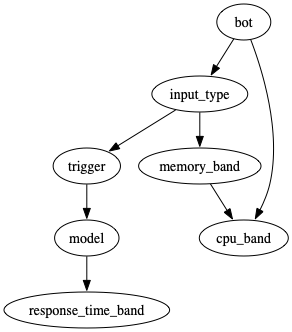

In [47]:
# render the learned graph
learned_graph_picture = learned_graph.to_graphviz()
learned_graph_picture.draw('learned_structure.png', format='png',
                           prog='dot')
Image('learned_structure.png')

**Findings:**
* `model -> response_time_band` is the **only** edge into Response Time. Input type, Trigger and Bot add no detectable information once the model is known, at this sample size and with quartile bands, which matches previous sections.
* Neither `model -> cpu_band` nor `model -> memory_band` appears. CPU instead takes its edge from `bot`, the workflow instance (Section 6.1), and memory takes its edge from `input_type`. One more edge, `memory_band -> cpu_band`, links the two resource readings.
* The remaining edges (`bot -> input_type`, `input_type -> trigger`, `trigger -> model`) describe how the benchmark scenarios were set up rather than performance.

---
# 9. Conclusions for model selection

| Finding | Evidence | Implication for a multi-model workflow |
| --- | --- | --- |
| Models differ sharply in speed | Means 11.8 to 71.8 s; all 95% intervals disjoint | Model choice is the main lever on Response Time |
| Response times are right-skewed | Skewness 0.89 to 1.16; mean above median in every model | Medians useful to users; size capacity and timeouts on the mean and the tail |
| Slow models are also unpredictable | SD 8.2 s (Qwen) to 56.7 s (Gemma); Gemma max 246 s | Avoid Gemma and Pixtral for latency-sensitive work |
| CPU % and Memory show no model difference | Tukey p >= 0.89; r near 0 with Response Time | Resource cost comes from duration, not intensity |
| Work per call does depend on the model | Gemma 5.07x Qwen in CPU-seconds; 19.7 CPU-hours per 1,000 calls | Routing to faster models saves CPU time |
| Answer length drives Response Time | r = 0.91; two tiers | Route by expected answer length |
| Memory follows the workflow | r about 0.50 with workflow time, about 0 with model time | Size memory for the workflow, not the model |

### Recommended routing
* **Short answers, latency-sensitive** (classification, tagging, quick replies): **qwen2-vl-7b-instruct**. Fastest at every quartile and at the maximum, worst case 33 s.
* **Long answers** (descriptions, summaries): **minicpm-o-2_6**. Writes answers about as long as gemma's in less than half the time per character, and is the least variable relative to its mean.
* **pixtral-12b and gemma-3-12b-it**: reserve for tasks where their output quality is shown to be worth about 4 to 6.5 times the typical wait and 3.5 to 5 times the CPU time.

*Answer quality was not measured, so these recommendations cover speed and CPU cost only.*